# Анализ причин снижения оборота в онлайн ретейлинговой компании

В этом ноутбуке я описываю причины падения ключевой метрики бизнеса с помощью данных о заказах, пользовательской воронки и маркетинговых коммуникациях за последние 6 месяцев. Анализ поделён на три основных этапа: EDA, анализ причин падения и расчеты для подтверждения выводов. В конце я подвожу итоги и даю рекомендации для бизнеса.

## 1. EDA

Целью данного этапа является поиск ключевой проблемы и её причин из доступных данных. С помощью них я отвечаю на следующие вопросы:
- Когда упала ключевая метрика?
- Что в поведении пользователей повлияло на падение?
- Как взаимосвязаны пользователи, их воронка и заказы?

### Чтение данных

Данные о заказах, воронке и маркетинговых коммуникациях загружаются локально:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
df_orders = pd.read_csv('grocery_delivery_orders_2025_11_2026_04.csv')
df_funnel = pd.read_csv('grocery_delivery_funnel_2025_11_2026_04.csv')
df_market = pd.read_csv('grocery_delivery_marketing_communications_2025_11_2026_04.csv')

In [3]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21884 entries, 0 to 21883
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   order_id                 21884 non-null  object 
 1   session_id               21884 non-null  object 
 2   client_id                21884 non-null  object 
 3   address_id               21884 non-null  object 
 4   store_id                 21884 non-null  object 
 5   city                     21884 non-null  object 
 6   platform                 21884 non-null  object 
 7   order_created_at         21884 non-null  object 
 8   order_date               21884 non-null  object 
 9   delivery_slot_start      21884 non-null  object 
 10  items_count              21884 non-null  int64  
 11  gross_merchandise_value  21884 non-null  float64
 12  discount_type            21884 non-null  object 
 13  discount_amount          21884 non-null  float64
 14  delivery_fee          

Данные по заказам полные, `campaign_id` отсутствует у заказов, в которых пользователи не получали коммуникации.

In [4]:
df_funnel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144710 entries, 0 to 144709
Data columns (total 23 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   session_id            144710 non-null  object
 1   client_id             144710 non-null  object
 2   address_id            144710 non-null  object
 3   session_start_at      144710 non-null  object
 4   session_date          144710 non-null  object
 5   city                  144710 non-null  object
 6   platform              144710 non-null  object
 7   traffic_source        144710 non-null  object
 8   campaign_id           6699 non-null    object
 9   experiment_group      144710 non-null  object
 10  timing_period         144710 non-null  object
 11  service_visit         144710 non-null  int64 
 12  product_search        144710 non-null  int64 
 13  product_card_view     144710 non-null  int64 
 14  add_to_cart           144710 non-null  int64 
 15  cart_visit       

Данные по сессиям тоже полные, `order_id` отсутствует у сессий, которые не перешли в заказ, `campaign_id` аналогично отсутствует у сессий, в которых пользователи были без коммуникаций. 

In [5]:
df_market.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72193 entries, 0 to 72192
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   communication_id    72193 non-null  object
 1   campaign_id         72193 non-null  object
 2   communication_type  72193 non-null  object
 3   client_id           72193 non-null  object
 4   send_datetime       72193 non-null  object
 5   send_date           72193 non-null  object
 6   send_hour           72193 non-null  int64 
 7   timing_period       72193 non-null  object
 8   experiment_group    72193 non-null  object
 9   send_status         72193 non-null  object
dtypes: int64(1), object(9)
memory usage: 5.5+ MB


Данные о коммуникациях полные.

### Анализ заказов через дерево метрик

Ключевая метрика бизнеса -- GMV. Разложим её на ключевые компоненты и визуализируем связи с помощью дерева метрик:

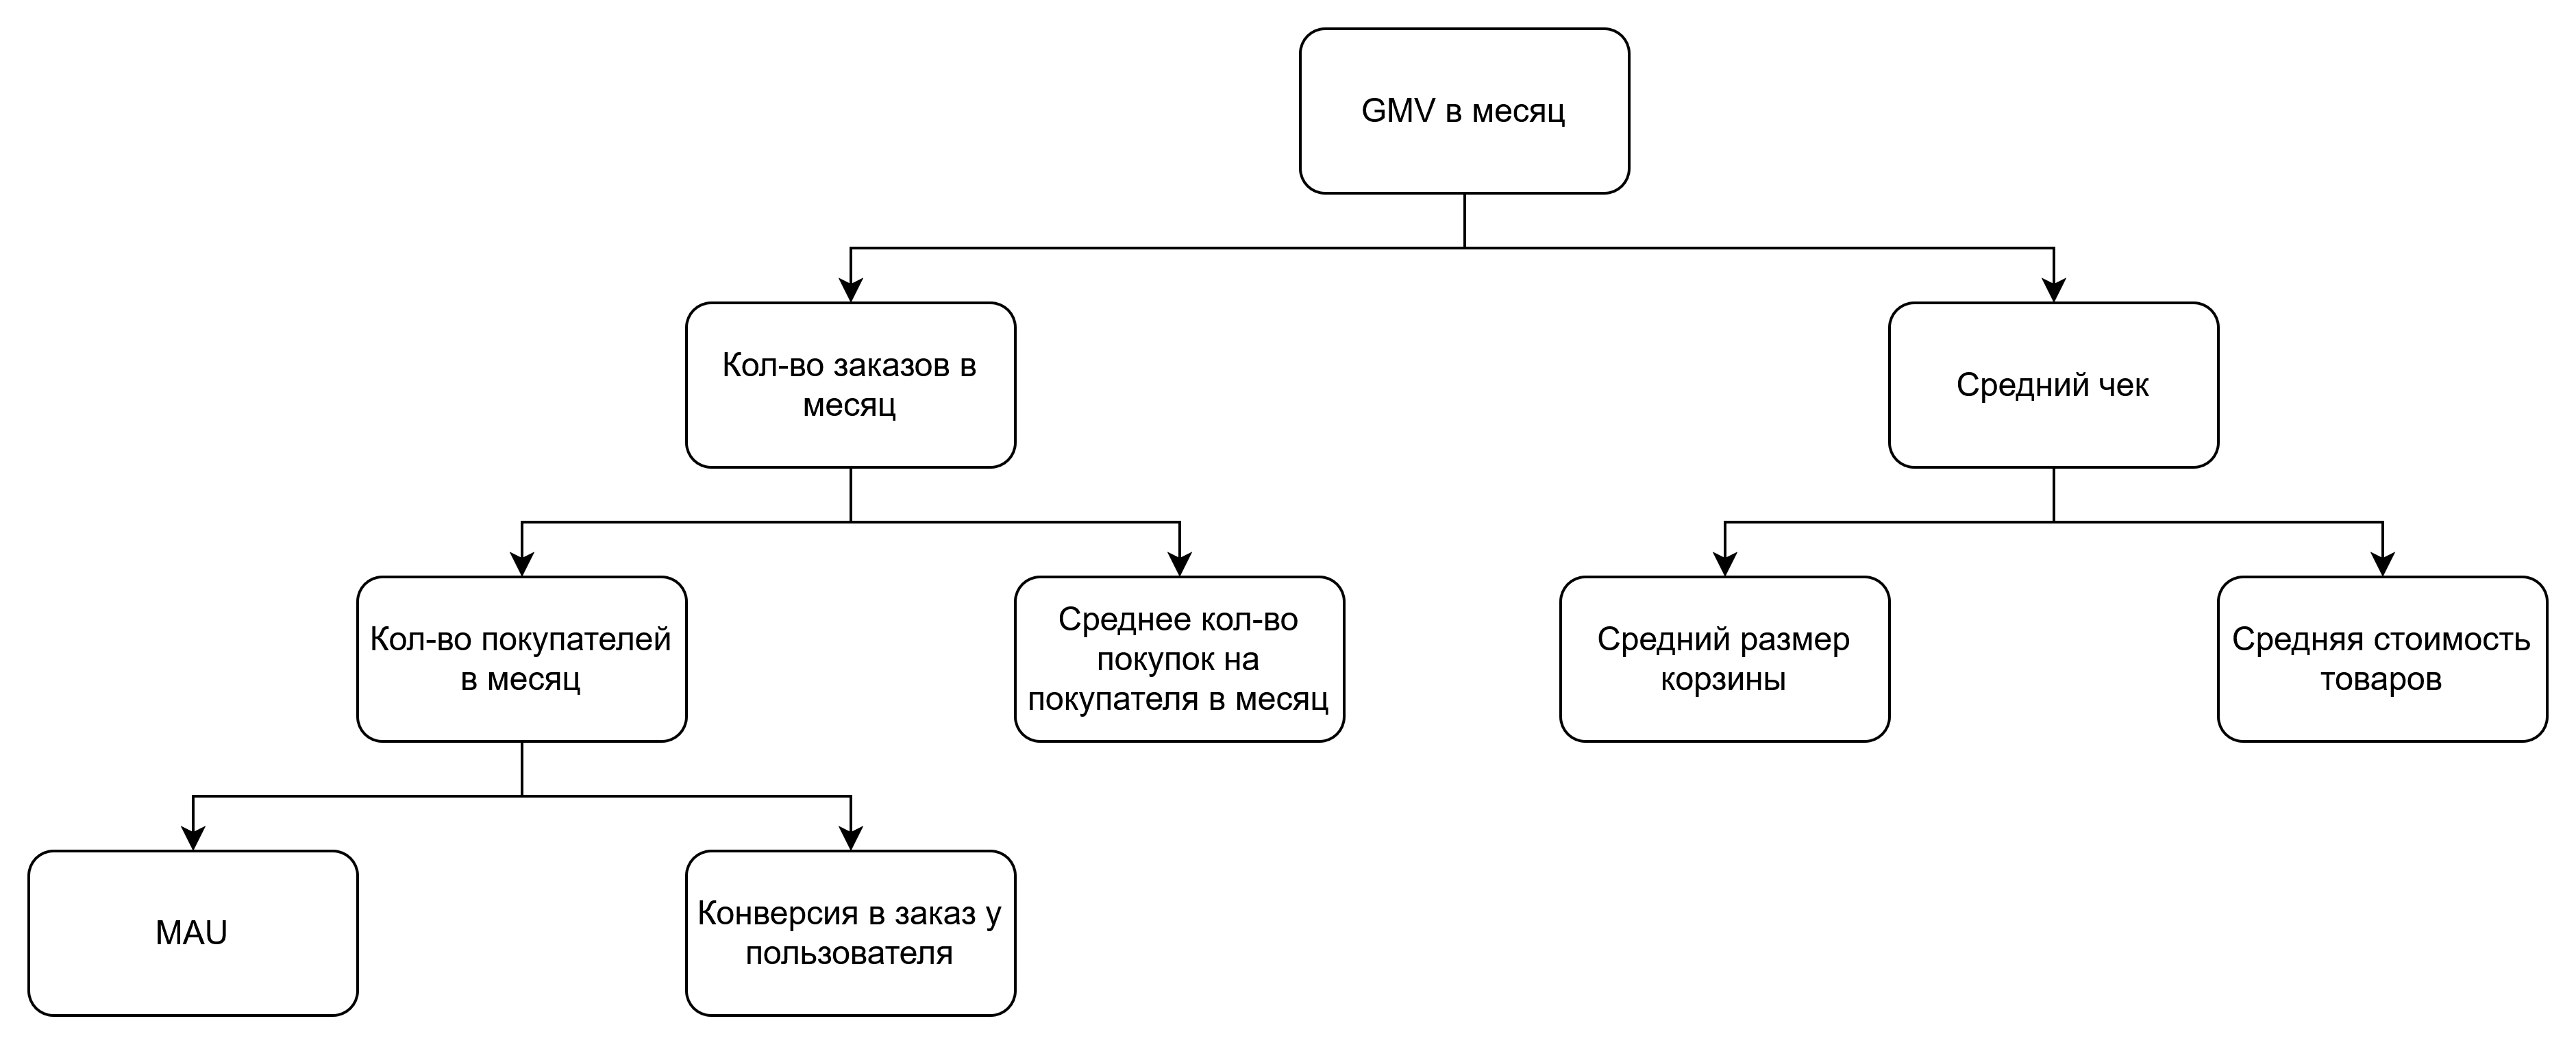

На этапе анализа заказов, рассмотрим верхние 3 уровня, далее -- перейдем на уровень конверсий.

In [6]:
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
df_orders['month'] = df_orders['order_date'].dt.strftime('%Y-%m')

monthly_orders_statistics =df_orders.groupby(['month']).agg(
    orders_count=pd.NamedAgg(column="order_id", aggfunc="count"),
    gmv=pd.NamedAgg(column="gross_merchandise_value", aggfunc="sum"),
    total_items_count=pd.NamedAgg(column="items_count", aggfunc="sum"),
    average_items_count=pd.NamedAgg(column="items_count", aggfunc="mean"),
    buyers_count=pd.NamedAgg(column="client_id", aggfunc="nunique")
).reset_index()

monthly_orders_statistics['aov'] = monthly_orders_statistics['gmv'] / monthly_orders_statistics['orders_count']
monthly_orders_statistics['average_orders_per_buyer'] = monthly_orders_statistics['orders_count'] / monthly_orders_statistics['buyers_count']
monthly_orders_statistics['average_items_price'] = monthly_orders_statistics['gmv'] / monthly_orders_statistics['total_items_count']

In [7]:
monthly_orders_statistics.columns

Index(['month', 'orders_count', 'gmv', 'total_items_count',
       'average_items_count', 'buyers_count', 'aov',
       'average_orders_per_buyer', 'average_items_price'],
      dtype='object')

Убедимся в наблюдаемом падении метрики за апрель 2026 года:

C:\Users\ilya-\AppData\Local\Temp\ipykernel_8604\1505414015.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  plt.plot(pd.to_datetime(monthly_orders_statistics['month']), monthly_orders_statistics['gmv'], marker='.', color='orange', label='GMV')


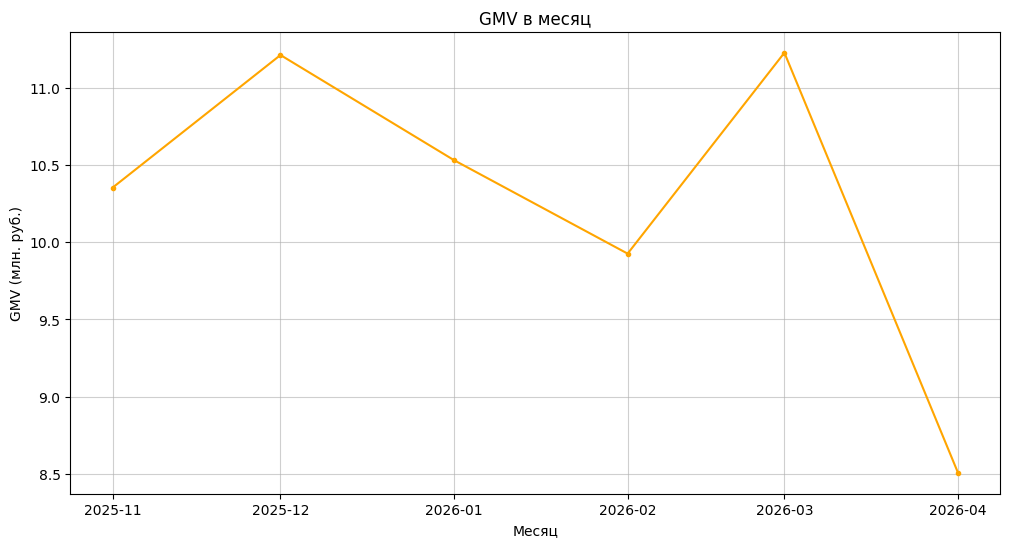

In [8]:
# Format y-axis as millions
def millions_formatter(x, pos):
    return f'{x / 1e6:.1f}'

plt.figure(figsize=(12, 6))

plt.title('GMV в месяц')
plt.xlabel('Месяц')
plt.ylabel('GMV (млн. руб.)')
plt.grid(True, alpha=0.6)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(millions_formatter))

plt.plot(pd.to_datetime(monthly_orders_statistics['month']), monthly_orders_statistics['gmv'], marker='.', color='orange', label='GMV')

GMV упал примерно на 2.5 млн. рублей за последний месяц. При этом стоит учесть, что в зимний период также произошло падение метрики.

Теперь оценим другие метрики из дерева, чтобы установить причины падения GMV:

#### Поддерево 1: GMV - Кол-во заказов - Средний чек

Посмотрим на процентные изменения метрик относительно значений на начальный период (ноябрь 2025).

C:\Users\ilya-\AppData\Local\Temp\ipykernel_8604\2930925166.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ax1.plot(pd.to_datetime(monthly_orders_statistics['month']), gmv_indexed, marker='.', color='orange', label='GMV')
C:\Users\ilya-\AppData\Local\Temp\ipykernel_8604\2930925166.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ax[1, 0].plot(pd.to_datetime(monthly_orders_statistics['month']), orders_count_indexed, marker='.', label='Orders count')
C:\Users\ilya-\AppData\Local\Temp\ipykernel_8604\2930925166.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ax[1

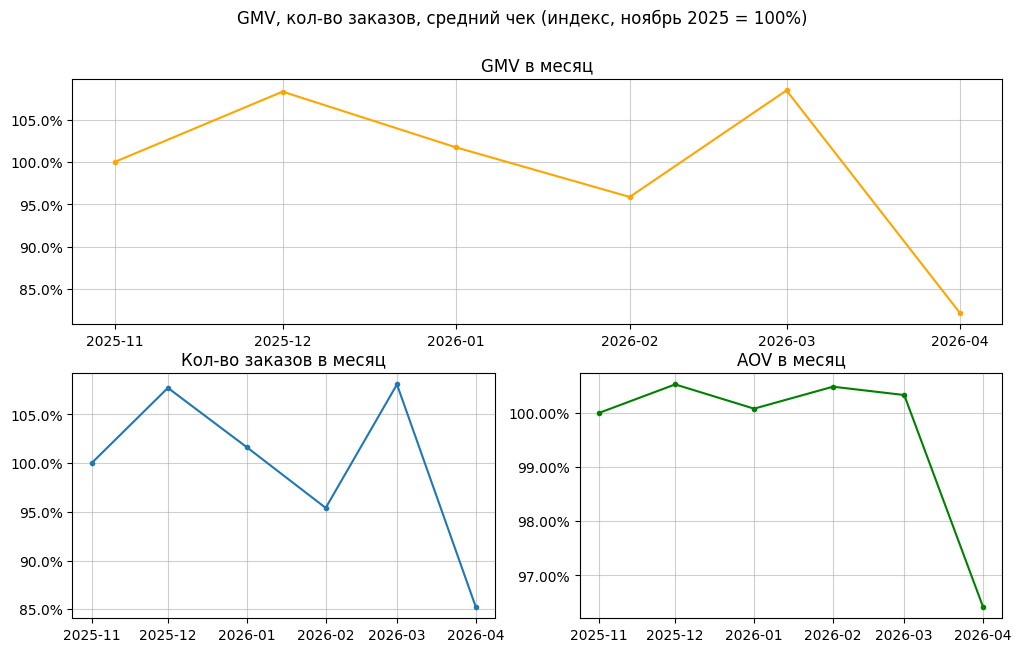

In [9]:
gmv_indexed = monthly_orders_statistics['gmv'] / monthly_orders_statistics['gmv'].iloc[0] * 100
orders_count_indexed = monthly_orders_statistics['orders_count'] / monthly_orders_statistics['orders_count'].iloc[0] * 100
aov_indexed = monthly_orders_statistics['aov'] / monthly_orders_statistics['aov'].iloc[0] * 100

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 7))

# Remove the top two subplots and replace with a single wide one
fig.delaxes(ax[0, 0])  # Remove first subplot
fig.delaxes(ax[0, 1])  # Remove second subplot

fig.suptitle('GMV, кол-во заказов, средний чек (индекс, ноябрь 2025 = 100%)')

ax1 = plt.subplot(2, 2, (1, 2))
ax1.set_title('GMV в месяц')
ax1.grid(True, alpha=0.6)
ax1.yaxis.set_major_formatter(ticker.PercentFormatter(100))

ax1.plot(pd.to_datetime(monthly_orders_statistics['month']), gmv_indexed, marker='.', color='orange', label='GMV')


ax[1, 0].plot(pd.to_datetime(monthly_orders_statistics['month']), orders_count_indexed, marker='.', label='Orders count')
ax[1, 0].set_title('Кол-во заказов в месяц')
ax[1, 0].grid(True, alpha=0.6)
ax[1, 0].yaxis.set_major_formatter(ticker.PercentFormatter(100))

ax[1, 1].plot(pd.to_datetime(monthly_orders_statistics['month']), aov_indexed, marker='.', color='green', label='AOV')
ax[1, 1].set_title('AOV в месяц')
ax[1, 1].grid(True, alpha=0.6)
ax[1, 1].yaxis.set_major_formatter(ticker.PercentFormatter(100))
plt.show()

Исходя из графика, относительно марта в апреле сильное падение произошло **в числе заказов (около 20%)**, тогда как в среднем чеке - около 4%.

#### Поддерево 2: Кол-во заказов - Кол-во покупателей - Среднее число покупок

C:\Users\ilya-\AppData\Local\Temp\ipykernel_8604\998628656.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ax1.plot(pd.to_datetime(monthly_orders_statistics['month']), orders_count_index, marker='.', color='orange', label='Orders Count')
C:\Users\ilya-\AppData\Local\Temp\ipykernel_8604\998628656.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ax[1, 0].plot(pd.to_datetime(monthly_orders_statistics['month']), buyers_count_index, marker='.', label='Buyers Count')
C:\Users\ilya-\AppData\Local\Temp\ipykernel_8604\998628656.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a for

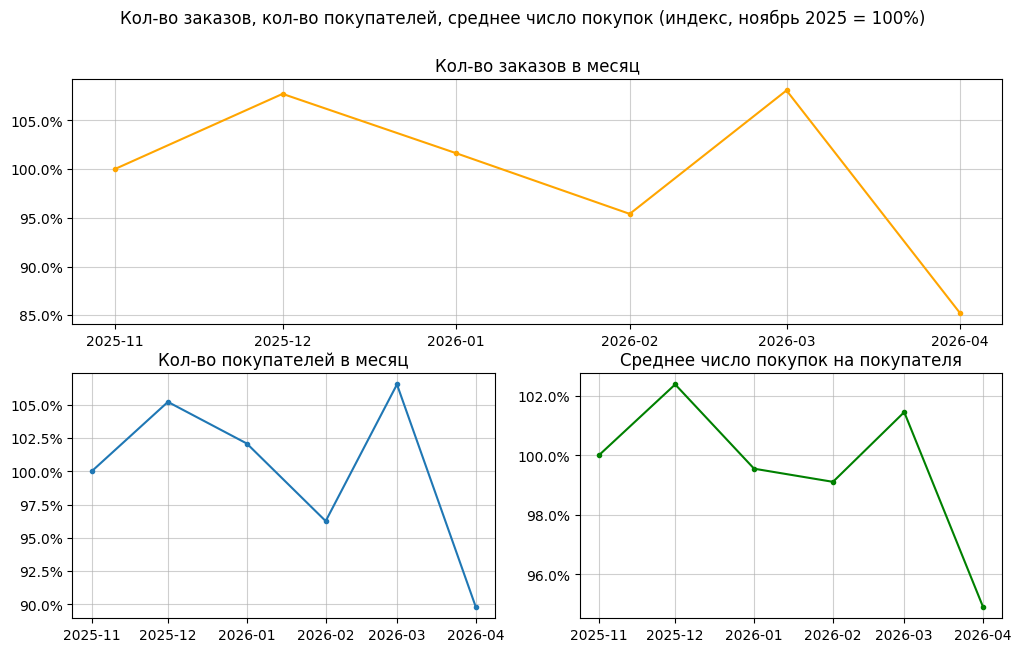

In [10]:
orders_count_index = monthly_orders_statistics['orders_count'] / monthly_orders_statistics['orders_count'].iloc[0] * 100
buyers_count_index = monthly_orders_statistics['buyers_count'] / monthly_orders_statistics['buyers_count'].iloc[0] * 100
average_orders_per_buyer_index = monthly_orders_statistics['average_orders_per_buyer'] / monthly_orders_statistics['average_orders_per_buyer'].iloc[0] * 100

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 7))

# Remove the top two subplots and replace with a single wide one
fig.delaxes(ax[0, 0])  # Remove first subplot
fig.delaxes(ax[0, 1])  # Remove second subplot

fig.suptitle('Кол-во заказов, кол-во покупателей, среднее число покупок (индекс, ноябрь 2025 = 100%)')

ax1 = plt.subplot(2, 2, (1, 2))
ax1.set_title('Кол-во заказов в месяц')
ax1.grid(True, alpha=0.6)
ax1.yaxis.set_major_formatter(ticker.PercentFormatter(100))

ax1.plot(pd.to_datetime(monthly_orders_statistics['month']), orders_count_index, marker='.', color='orange', label='Orders Count')


ax[1, 0].plot(pd.to_datetime(monthly_orders_statistics['month']), buyers_count_index, marker='.', label='Buyers Count')
ax[1, 0].set_title('Кол-во покупателей в месяц')
ax[1, 0].grid(True, alpha=0.6)
ax[1, 0].yaxis.set_major_formatter(ticker.PercentFormatter(100))

ax[1, 1].plot(pd.to_datetime(monthly_orders_statistics['month']), average_orders_per_buyer_index, marker='.', color='green', label='Average Orders per Buyer')
ax[1, 1].set_title('Среднее число покупок на покупателя')
ax[1, 1].grid(True, alpha=0.6)
ax[1, 1].yaxis.set_major_formatter(ticker.PercentFormatter(100))

plt.show()

В данном случае, количество покупок падает за счет **уменьшения числа покупателей** (около 15% за апрель относительно марта) и **числа покупок** (около 6.5%).

#### Поддерево 3: Средний чек - Средний размер корзины - Средняя цена товаров

C:\Users\ilya-\AppData\Local\Temp\ipykernel_8604\2435762912.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ax1.plot(pd.to_datetime(monthly_orders_statistics['month']), aov_indexed, marker='.', color='orange', label='AOV')
C:\Users\ilya-\AppData\Local\Temp\ipykernel_8604\2435762912.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ax[1, 0].plot(pd.to_datetime(monthly_orders_statistics['month']), average_items_count_indexed, marker='.', label='Average Items Count')
C:\Users\ilya-\AppData\Local\Temp\ipykernel_8604\2435762912.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a 

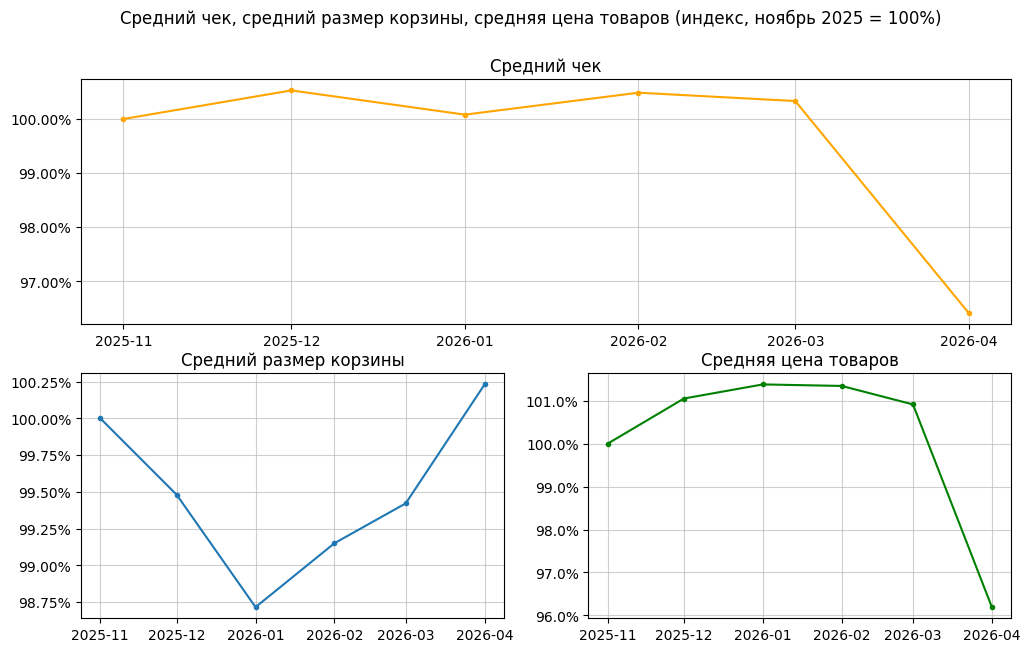

In [11]:
aov_indexed = monthly_orders_statistics['aov'] / monthly_orders_statistics['aov'].iloc[0] * 100
average_items_count_indexed = monthly_orders_statistics['average_items_count'] / monthly_orders_statistics['average_items_count'].iloc[0] * 100
average_items_price_indexed = monthly_orders_statistics['average_items_price'] / monthly_orders_statistics['average_items_price'].iloc[0] * 100

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 7))

# Remove the top two subplots and replace with a single wide one
fig.delaxes(ax[0, 0])  # Remove first subplot
fig.delaxes(ax[0, 1])  # Remove second subplot

fig.suptitle('Средний чек, средний размер корзины, средняя цена товаров (индекс, ноябрь 2025 = 100%)')

ax1 = plt.subplot(2, 2, (1, 2))
ax1.set_title('Средний чек')
ax1.grid(True, alpha=0.6)
ax1.yaxis.set_major_formatter(ticker.PercentFormatter(100))

ax1.plot(pd.to_datetime(monthly_orders_statistics['month']), aov_indexed, marker='.', color='orange', label='AOV')


ax[1, 0].plot(pd.to_datetime(monthly_orders_statistics['month']), average_items_count_indexed, marker='.', label='Average Items Count')
ax[1, 0].set_title('Средний размер корзины')
ax[1, 0].grid(True, alpha=0.6)
ax[1, 0].yaxis.set_major_formatter(ticker.PercentFormatter(100))

ax[1, 1].plot(pd.to_datetime(monthly_orders_statistics['month']), average_items_price_indexed, marker='.', color='green', label='Average Items Price')
ax[1, 1].set_title('Средняя цена товаров')
ax[1, 1].grid(True, alpha=0.6)
ax[1, 1].yaxis.set_major_formatter(ticker.PercentFormatter(100))

plt.show()

Средний чек падает из-за **падения средней цены товаров**. Размер корзины, напротив, незначительно растет.

**Итог**: отвечая на поставленный вопрос о падении метрики и ключевых факторах, мы выделяем уменьшение GMV в апреле 2026 за счет падения ключевых компонент: кол-ва заказов (в свою очередь из-за изменения среднего числа покупателей и среднего числа покупок) и среднего чека (из-за падения средней стоимости товаров).

### Анализ по сегментам

Кроме показателей заказов, в датасете присутствуют данные о пользователях, совершивших покупки. В данном подразделе исследуются сегменты пользователей, чтобы локализовать группы, в которых произошло падение.

#### По городам

In [12]:
monthly_orders_statistics_by_city =df_orders.groupby(['city', 'month']).agg(
    orders_count=pd.NamedAgg(column="order_id", aggfunc="count"),
    gmv=pd.NamedAgg(column="gross_merchandise_value", aggfunc="sum"),
    total_items_count=pd.NamedAgg(column="items_count", aggfunc="sum"),
    average_items_count=pd.NamedAgg(column="items_count", aggfunc="mean"),
    buyers_count=pd.NamedAgg(column="client_id", aggfunc="nunique")
).reset_index()

monthly_orders_statistics_by_city['aov'] = monthly_orders_statistics_by_city['gmv'] / monthly_orders_statistics_by_city['orders_count']
monthly_orders_statistics_by_city['average_orders_per_buyer'] = monthly_orders_statistics_by_city['orders_count'] / monthly_orders_statistics_by_city['buyers_count']
monthly_orders_statistics_by_city['average_items_price'] = monthly_orders_statistics_by_city['gmv'] / monthly_orders_statistics_by_city['total_items_count']

In [13]:
# Ensure datetime and sort
monthly_orders_statistics_by_city['month'] = pd.to_datetime(monthly_orders_statistics_by_city['month'])
monthly_orders_statistics_by_city = monthly_orders_statistics_by_city.sort_values(['city', 'month'])

# Pivot: each city becomes a column, index=month, values=GMV
gmv_pivot = monthly_orders_statistics_by_city.pivot(index='month', columns='city', values='gmv')

# Index all series to 100 at the first observed value
gmv_indexed = (gmv_pivot / gmv_pivot.iloc[0]) * 100

C:\Users\ilya-\AppData\Local\Temp\ipykernel_8604\4036881411.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  monthly_orders_statistics_by_city['month'] = pd.to_datetime(monthly_orders_statistics_by_city['month'])


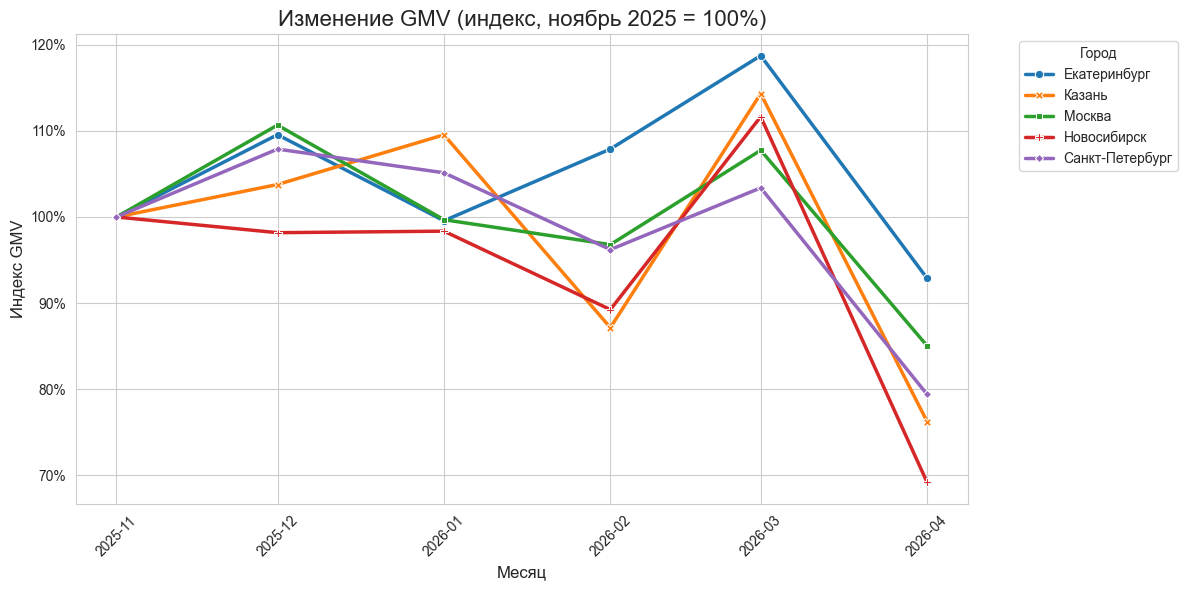

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.lineplot(data=gmv_indexed, markers=True, linewidth=2.5, dashes=False)

plt.title('Изменение GMV (индекс, ноябрь 2025 = 100%)', fontsize=16)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Индекс GMV', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Город', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(100))

plt.tight_layout()
plt.show()

Исходя из графика, можем сделать вывод, что по городам динамика схожая.

#### По платформам

In [15]:
monthly_orders_statistics_by_platform =df_orders.groupby(['platform', 'month']).agg(
    orders_count=pd.NamedAgg(column="order_id", aggfunc="count"),
    gmv=pd.NamedAgg(column="gross_merchandise_value", aggfunc="sum"),
    total_items_count=pd.NamedAgg(column="items_count", aggfunc="sum"),
    average_items_count=pd.NamedAgg(column="items_count", aggfunc="mean"),
    buyers_count=pd.NamedAgg(column="client_id", aggfunc="nunique")
).reset_index()

monthly_orders_statistics_by_platform['aov'] = monthly_orders_statistics_by_platform['gmv'] / monthly_orders_statistics_by_platform['orders_count']
monthly_orders_statistics_by_platform['average_orders_per_buyer'] = monthly_orders_statistics_by_platform['orders_count'] / monthly_orders_statistics_by_platform['buyers_count']
monthly_orders_statistics_by_platform['average_items_price'] = monthly_orders_statistics_by_platform['gmv'] / monthly_orders_statistics_by_platform['total_items_count']

In [16]:
# Ensure datetime and sort
monthly_orders_statistics_by_platform['month'] = pd.to_datetime(monthly_orders_statistics_by_platform['month'])
monthly_orders_statistics_by_platform = monthly_orders_statistics_by_platform.sort_values(['platform', 'month'])

# Pivot: each platform becomes a column, index=month, values=GMV
gmv_pivot = monthly_orders_statistics_by_platform.pivot(index='month', columns='platform', values='gmv')

# Index all series to 100 at the first observed value
gmv_indexed = (gmv_pivot / gmv_pivot.iloc[0]) * 100

C:\Users\ilya-\AppData\Local\Temp\ipykernel_8604\1809169715.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  monthly_orders_statistics_by_platform['month'] = pd.to_datetime(monthly_orders_statistics_by_platform['month'])


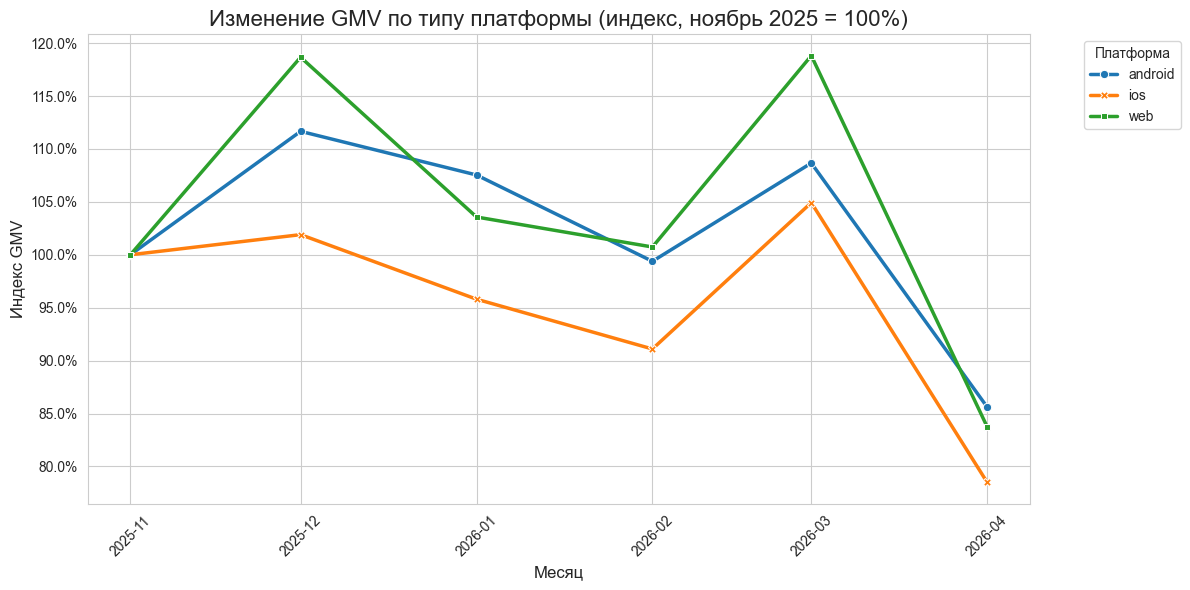

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.lineplot(data=gmv_indexed, markers=True, linewidth=2.5, dashes=False)

plt.title('Изменение GMV по типу платформы (индекс, ноябрь 2025 = 100%)', fontsize=16)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Индекс GMV', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Платформа', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(100))

plt.tight_layout()
plt.show()

По платформам сильных различий аналогично не видно.

#### Тип оплаты

In [18]:
monthly_orders_statistics_by_payment =df_orders.groupby(['payment_method', 'month']).agg(
    orders_count=pd.NamedAgg(column="order_id", aggfunc="count"),
    gmv=pd.NamedAgg(column="gross_merchandise_value", aggfunc="sum"),
    total_items_count=pd.NamedAgg(column="items_count", aggfunc="sum"),
    average_items_count=pd.NamedAgg(column="items_count", aggfunc="mean"),
    buyers_count=pd.NamedAgg(column="client_id", aggfunc="nunique")
).reset_index()

monthly_orders_statistics_by_payment['aov'] = monthly_orders_statistics_by_payment['gmv'] / monthly_orders_statistics_by_payment['orders_count']
monthly_orders_statistics_by_payment['average_orders_per_buyer'] = monthly_orders_statistics_by_payment['orders_count'] / monthly_orders_statistics_by_payment['buyers_count']
monthly_orders_statistics_by_payment['average_items_price'] = monthly_orders_statistics_by_payment['gmv'] / monthly_orders_statistics_by_payment['total_items_count']

In [19]:
# Ensure datetime and sort
monthly_orders_statistics_by_payment['month'] = pd.to_datetime(monthly_orders_statistics_by_payment['month'])
monthly_orders_statistics_by_payment = monthly_orders_statistics_by_payment.sort_values(['payment_method', 'month'])

# Pivot: each payment method becomes a column, index=month, values=GMV
gmv_pivot = monthly_orders_statistics_by_payment.pivot(index='month', columns='payment_method', values='gmv')

# Index all series to 100 at the first observed value
gmv_indexed = (gmv_pivot / gmv_pivot.iloc[0]) * 100

C:\Users\ilya-\AppData\Local\Temp\ipykernel_8604\692868713.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  monthly_orders_statistics_by_payment['month'] = pd.to_datetime(monthly_orders_statistics_by_payment['month'])


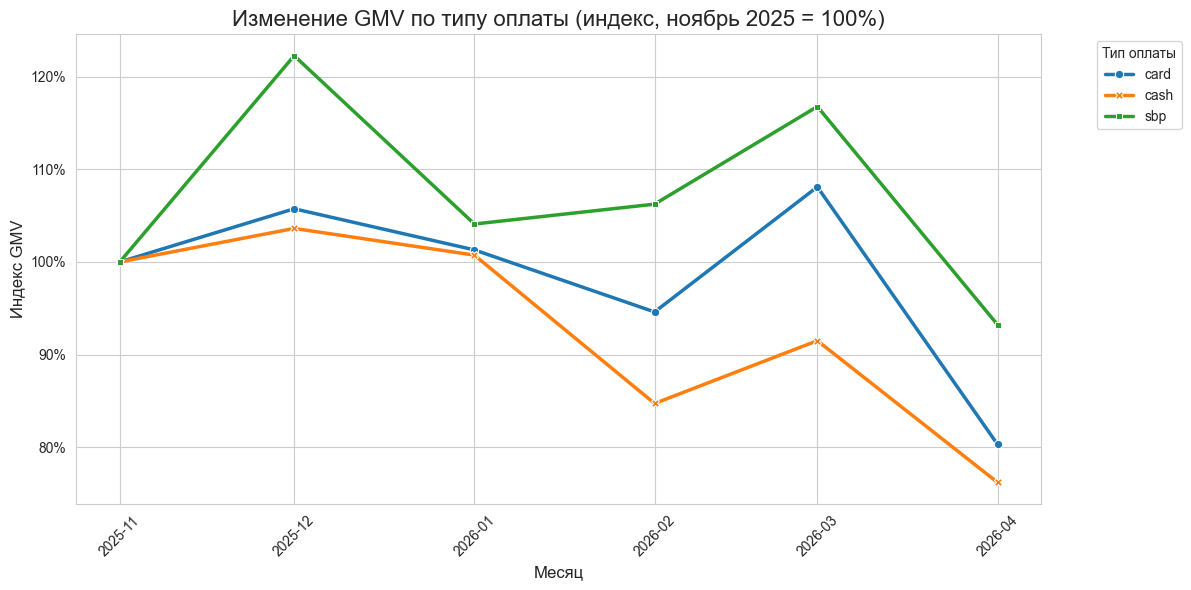

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.lineplot(data=gmv_indexed, markers=True, linewidth=2.5, dashes=False)

plt.title('Изменение GMV по типу оплаты (индекс, ноябрь 2025 = 100%)', fontsize=16)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Индекс GMV', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Тип оплаты', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(100))

plt.tight_layout()
plt.show()

Графики изменений схожи и по типу оплаты.

#### По влиянию маркетинга

In [21]:
monthly_orders_statistics_by_marketing =df_orders.groupby(['is_marketing_touched', 'month']).agg(
    orders_count=pd.NamedAgg(column="order_id", aggfunc="count"),
    gmv=pd.NamedAgg(column="gross_merchandise_value", aggfunc="sum"),
    total_items_count=pd.NamedAgg(column="items_count", aggfunc="sum"),
    average_items_count=pd.NamedAgg(column="items_count", aggfunc="mean"),
    buyers_count=pd.NamedAgg(column="client_id", aggfunc="nunique")
).reset_index()

monthly_orders_statistics_by_marketing['aov'] = monthly_orders_statistics_by_marketing['gmv'] / monthly_orders_statistics_by_marketing['orders_count']
monthly_orders_statistics_by_marketing['average_orders_per_buyer'] = monthly_orders_statistics_by_marketing['orders_count'] / monthly_orders_statistics_by_marketing['buyers_count']
monthly_orders_statistics_by_marketing['average_items_price'] = monthly_orders_statistics_by_marketing['gmv'] / monthly_orders_statistics_by_marketing['total_items_count']

In [22]:
# Ensure datetime and sort
monthly_orders_statistics_by_marketing['month'] = pd.to_datetime(monthly_orders_statistics_by_marketing['month'])
monthly_orders_statistics_by_marketing = monthly_orders_statistics_by_marketing.sort_values(['is_marketing_touched', 'month'])

# Pivot: each payment method becomes a column, index=month, values=GMV
gmv_pivot = monthly_orders_statistics_by_marketing.pivot(index='month', columns='is_marketing_touched', values='gmv')

# Index all series to 100 at the first observed value
gmv_indexed = (gmv_pivot / gmv_pivot.iloc[0]) * 100

C:\Users\ilya-\AppData\Local\Temp\ipykernel_8604\2026770725.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  monthly_orders_statistics_by_marketing['month'] = pd.to_datetime(monthly_orders_statistics_by_marketing['month'])


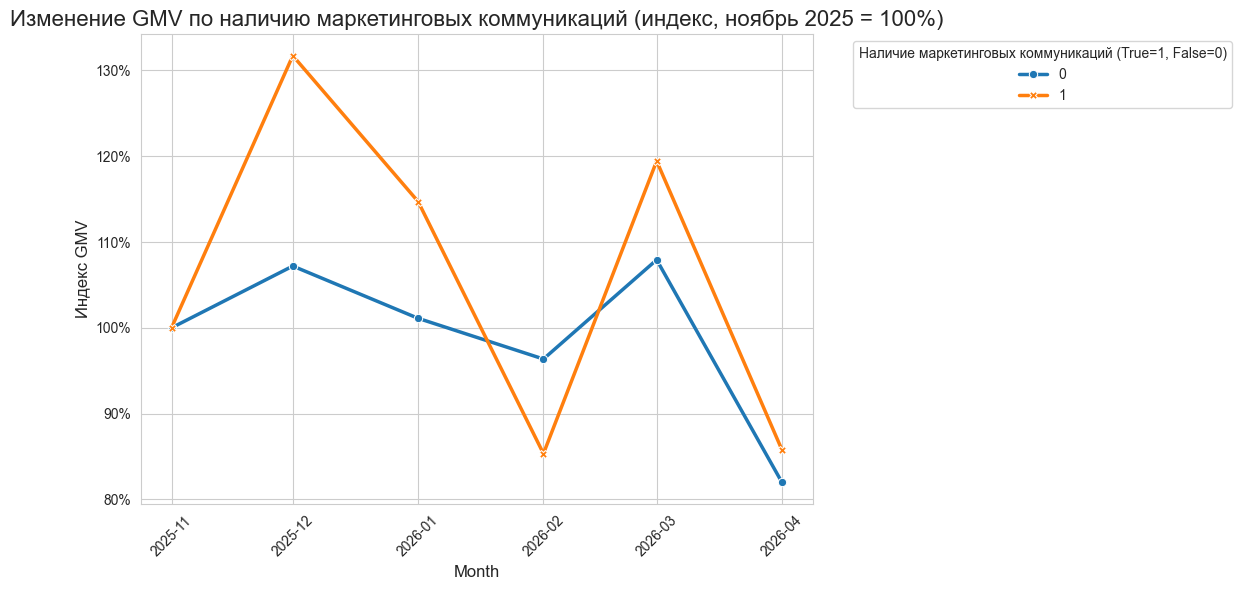

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.lineplot(data=gmv_indexed, markers=True, linewidth=2.5, dashes=False)

plt.title('Изменение GMV по наличию маркетинговых коммуникаций (индекс, ноябрь 2025 = 100%)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Индекс GMV', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Наличие маркетинговых коммуникаций (True=1, False=0)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(100))


plt.tight_layout()
plt.show()

Падение GMV за апрель примерно одинаковое в обеих группах.

#### Сезонность (будние дни / выходные дни)

In [24]:
df_orders['weekend'] = df_orders['order_date'].dt.weekday.isin([5,6])

Text(0, 0.5, 'Кол-во выходных')

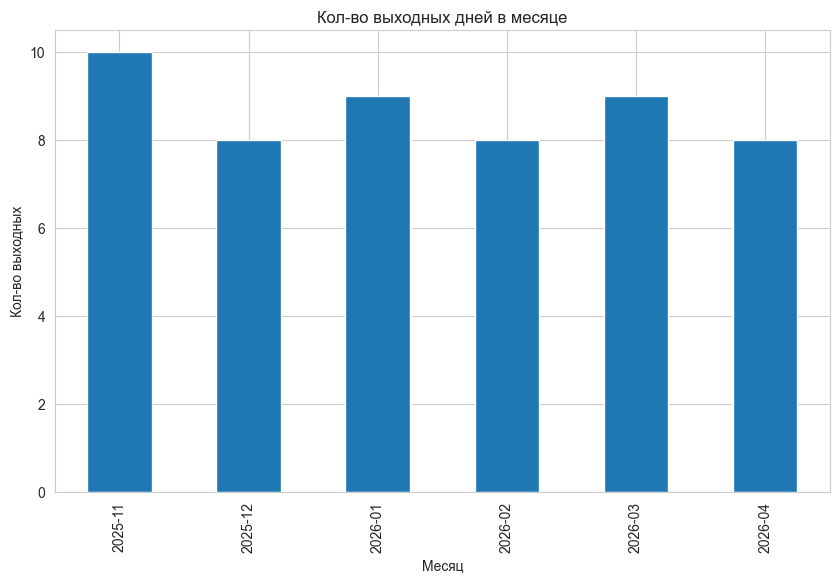

In [25]:
plt.figure(figsize=(10, 6))


plt.title('Кол-во выходных дней в месяце')

df_orders.groupby(['month', 'order_date'])['weekend'].any().groupby('month').sum().plot(kind='bar')

plt.xlabel('Месяц')
plt.ylabel('Кол-во выходных')

В апреле на один выходной меньше, чем в марте, что могло повлиять на продажи.

In [26]:
monthly_orders_statistics_by_weekday =df_orders.groupby(['weekend', 'month']).agg(
    orders_count=pd.NamedAgg(column="order_id", aggfunc="count"),
    gmv=pd.NamedAgg(column="gross_merchandise_value", aggfunc="sum"),
    total_items_count=pd.NamedAgg(column="items_count", aggfunc="sum"),
    average_items_count=pd.NamedAgg(column="items_count", aggfunc="mean"),
    buyers_count=pd.NamedAgg(column="client_id", aggfunc="nunique")
).reset_index()

monthly_orders_statistics_by_weekday['aov'] = monthly_orders_statistics_by_weekday['gmv'] / monthly_orders_statistics_by_weekday['orders_count']
monthly_orders_statistics_by_weekday['average_orders_per_buyer'] = monthly_orders_statistics_by_weekday['orders_count'] / monthly_orders_statistics_by_weekday['buyers_count']
monthly_orders_statistics_by_weekday['average_items_price'] = monthly_orders_statistics_by_weekday['gmv'] / monthly_orders_statistics_by_weekday['total_items_count']

Text(0, 0.5, 'Кол-во заказов')

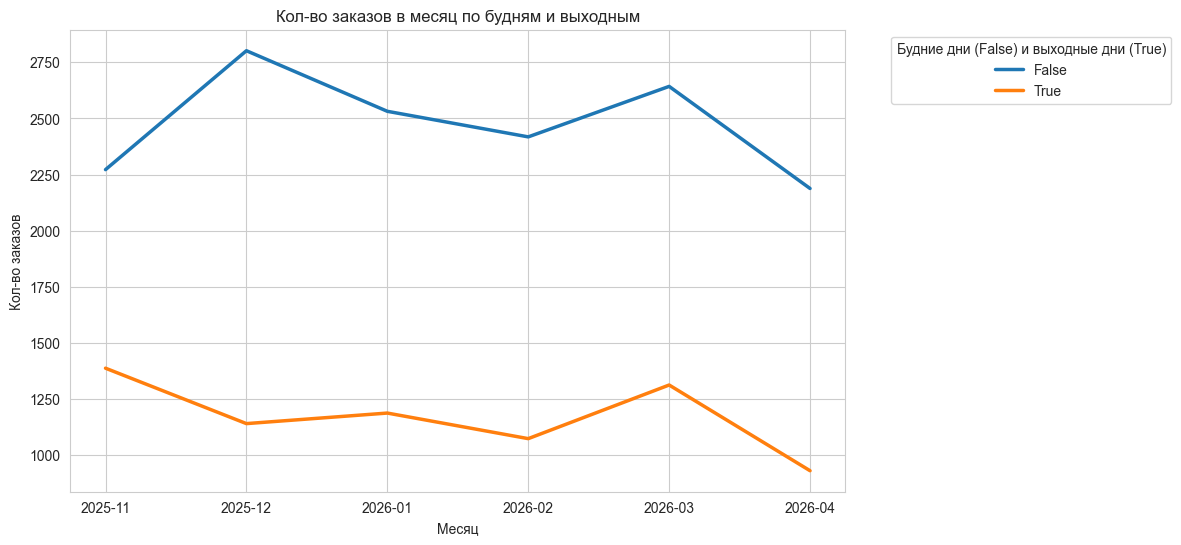

In [27]:
plt.figure(figsize=(10, 6))

plt.title('Кол-во заказов в месяц по будням и выходным')

sns.lineplot(data=monthly_orders_statistics_by_weekday, x='month', y='orders_count', hue='weekend', markers=True, linewidth=2.5, dashes=False)

plt.legend(title='Будние дни (False) и выходные дни (True)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xlabel('Месяц')
plt.ylabel('Кол-во заказов')

По выходным дням заказов примерно в 1.5 раза меньше, что уменьшает влияние меньшего числа выходных. Посмотрим на динамику по данному срезу:

In [28]:
# Ensure datetime and sort
monthly_orders_statistics_by_weekday['month'] = pd.to_datetime(monthly_orders_statistics_by_weekday['month'])
monthly_orders_statistics_by_weekday = monthly_orders_statistics_by_weekday.sort_values(['weekend', 'month'])

# Pivot: each payment method becomes a column, index=month, values=orders_count
orders_pivot = monthly_orders_statistics_by_weekday.pivot(index='month', columns='weekend', values='orders_count')

# Index all series to 100 at the first observed value
orders_indexed = (orders_pivot / orders_pivot.iloc[0]) * 100
orders_indexed = orders_indexed.reset_index().melt(id_vars='month', var_name='weekend', value_name='orders_indexed')

C:\Users\ilya-\AppData\Local\Temp\ipykernel_8604\1011550136.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  monthly_orders_statistics_by_weekday['month'] = pd.to_datetime(monthly_orders_statistics_by_weekday['month'])


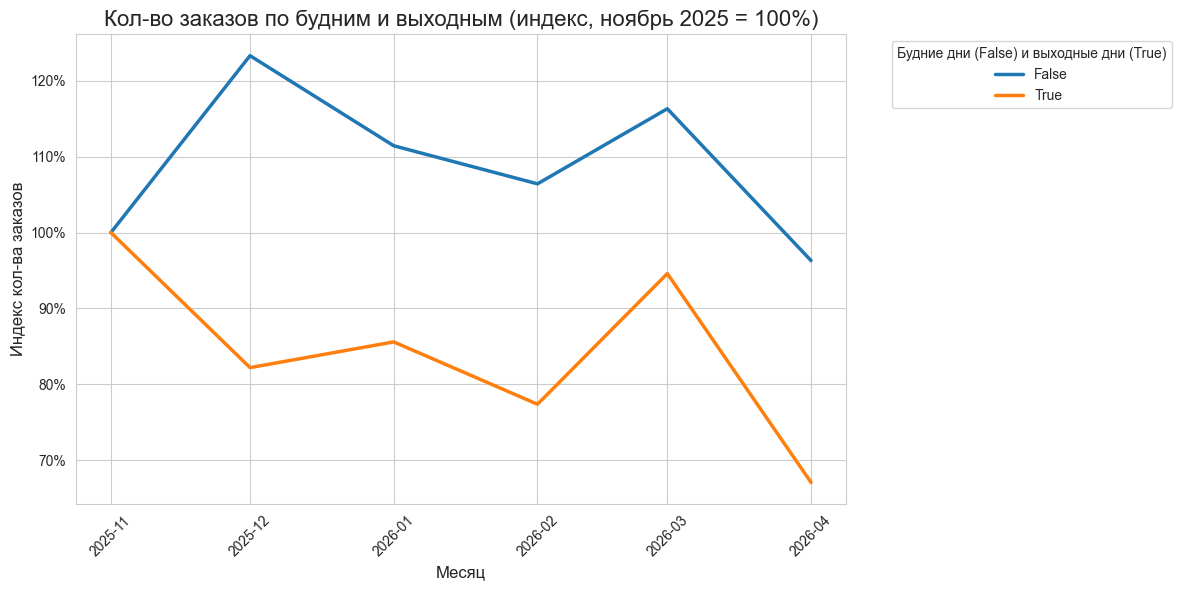

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.lineplot(data=orders_indexed, x='month', y='orders_indexed', hue='weekend', markers=True, linewidth=2.5, dashes=False)

plt.title('Кол-во заказов по будним и выходным (индекс, ноябрь 2025 = 100%)', fontsize=16)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Индекс кол-ва заказов', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Будние дни (False) и выходные дни (True)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(100))


plt.tight_layout()
plt.show()

In [30]:
# Pivot: each payment method becomes a column, index=month, values=orders_count
gmv_pivot = monthly_orders_statistics_by_weekday.pivot(index='month', columns='weekend', values='gmv')

# Index all series to 100 at the first observed value
gmv_indexed = (gmv_pivot / gmv_pivot.iloc[0]) * 100
gmv_indexed = gmv_indexed.reset_index().melt(id_vars='month', var_name='weekend', value_name='gmv_indexed')

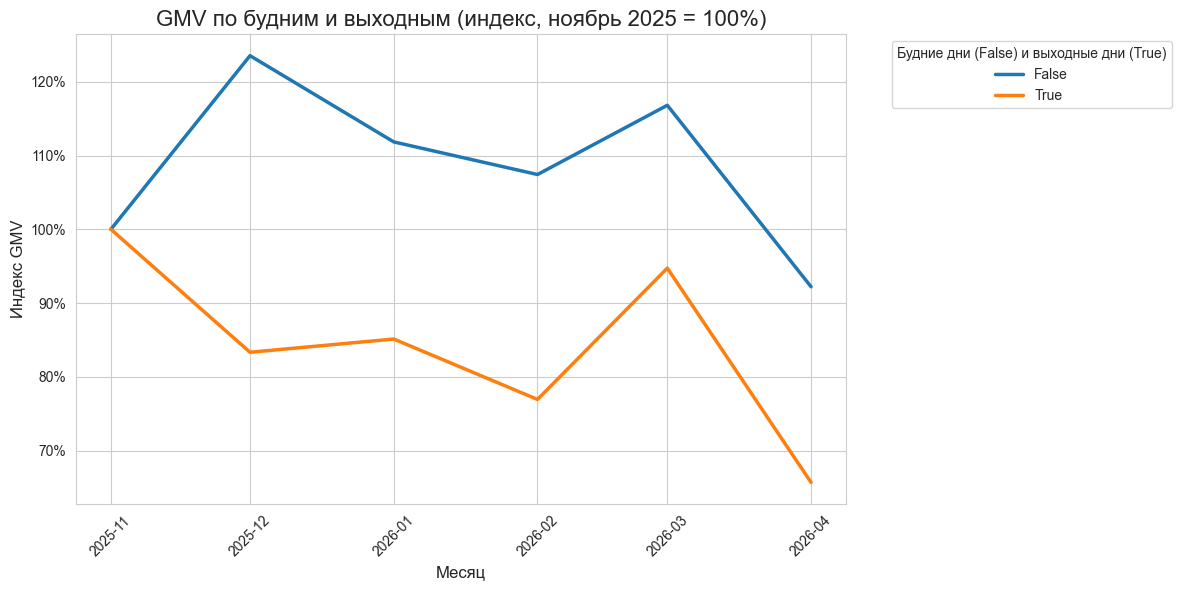

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.lineplot(data=gmv_indexed, x='month', y='gmv_indexed', hue='weekend', markers=True, linewidth=2.5, dashes=False)

plt.title('GMV по будним и выходным (индекс, ноябрь 2025 = 100%)', fontsize=16)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Индекс GMV', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Будние дни (False) и выходные дни (True)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(100))


plt.tight_layout()
plt.show()

Линии тренда падения в обоих срезах параллельны.

**Итог**: по различным срезам изменения однородны, нет групп с заметными отличиями.

### Анализ сессий

Продолжая декомпозицию GMV, мы спускаемся на последний уровень дерева -- разложение числа покупателей на MAU и конверсию в покупку. Для этого мы разберем пользовательскую воронку и локализуем падение конверсии:

Подготовим нужные форматы данных и сделаем замер времени переходов между этапами воронки:

In [32]:
df_funnel['session_date'] = pd.to_datetime(df_funnel['session_date'])

df_funnel['month'] = df_funnel['session_date'].dt.strftime("%Y-%m")

In [33]:
df_funnel[
    ['session_start_at', 'search_at', 'product_card_view_at', 'add_to_cart_at', 'cart_visit_at', 'purchase_at']
] = df_funnel[
    ['session_start_at', 'search_at', 'product_card_view_at', 'add_to_cart_at', 'cart_visit_at', 'purchase_at']
].apply(pd.to_datetime, errors='coerce')


conversion_timings = ['visit-search-timing', 'search-card-timing', 'card-add-timing', 'add-cart-timing', 'cart-purchase-timing']

df_funnel['visit-search-timing'] = (df_funnel['search_at'] - df_funnel['session_start_at']).dt.total_seconds() / 60
df_funnel['search-card-timing'] = (df_funnel['product_card_view_at'] - df_funnel['search_at']).dt.total_seconds() / 60
df_funnel['card-add-timing'] = (df_funnel['add_to_cart_at'] - df_funnel['product_card_view_at']).dt.total_seconds() / 60
df_funnel['add-cart-timing'] = (df_funnel['cart_visit_at'] - df_funnel['add_to_cart_at']).dt.total_seconds() / 60
df_funnel['cart-purchase-timing'] = (df_funnel['purchase_at'] - df_funnel['cart_visit_at']).dt.total_seconds() / 60

In [34]:
monthly_funnel_statistics = df_funnel.groupby(['month']).agg({
    'client_id': 'nunique',
    'service_visit': 'sum',
    'product_search': 'sum',
    'product_card_view': 'sum',
    'add_to_cart': 'sum',
    'cart_visit': 'sum',
    'purchase': 'sum',
    'visit-search-timing': 'mean',
    'search-card-timing': 'mean',
    'card-add-timing': 'mean',
    'add-cart-timing': 'mean',
    'cart-purchase-timing': 'mean'
}).reset_index()

conversions = ['visit-search', 'search-card', 'card-add', 'add-cart', 'cart-purchase', 'visit-purchase']

monthly_funnel_statistics['visit-search'] = monthly_funnel_statistics['product_search'] / monthly_funnel_statistics['service_visit']
monthly_funnel_statistics['search-card'] = monthly_funnel_statistics['product_card_view'] / monthly_funnel_statistics['product_search']
monthly_funnel_statistics['card-add'] = monthly_funnel_statistics['add_to_cart'] / monthly_funnel_statistics['product_card_view']
monthly_funnel_statistics['add-cart'] = monthly_funnel_statistics['cart_visit'] / monthly_funnel_statistics['add_to_cart']
monthly_funnel_statistics['cart-purchase'] = monthly_funnel_statistics['purchase'] / monthly_funnel_statistics['cart_visit']
monthly_funnel_statistics['visit-purchase'] = monthly_funnel_statistics['purchase'] / monthly_funnel_statistics['service_visit']

Проанализируем динамику по сессиям:

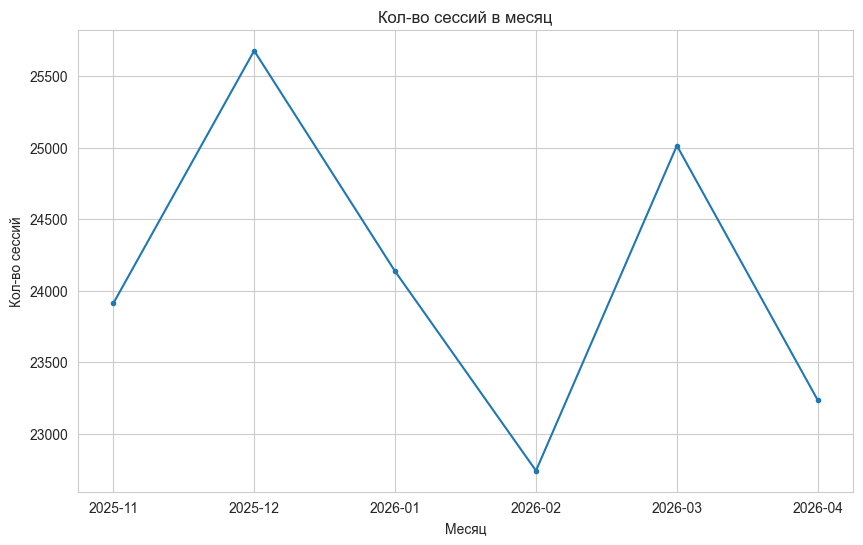

In [35]:
plt.figure(figsize=(10, 6))

plt.title('Кол-во сессий в месяц')
plt.xlabel('Месяц')
plt.ylabel('Кол-во сессий')

plt.plot(monthly_funnel_statistics['month'], monthly_funnel_statistics['service_visit'], marker='.')

Наблюдается падение за апрель (около 7% относительно марта).

Теперь посмотрим на пользователей за месяц:

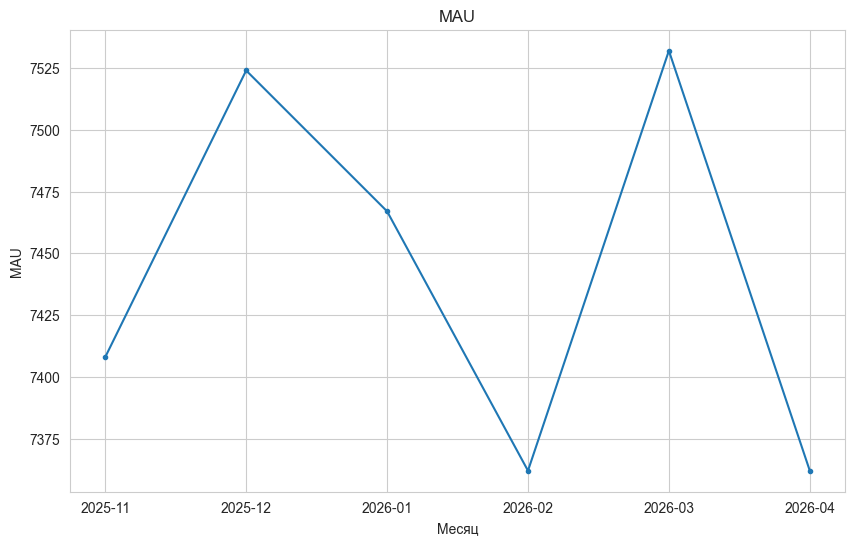

In [36]:
plt.figure(figsize=(10, 6))

plt.title('MAU')
plt.xlabel('Месяц')
plt.ylabel('MAU')

plt.plot(monthly_funnel_statistics['month'], monthly_funnel_statistics['client_id'], marker='.')

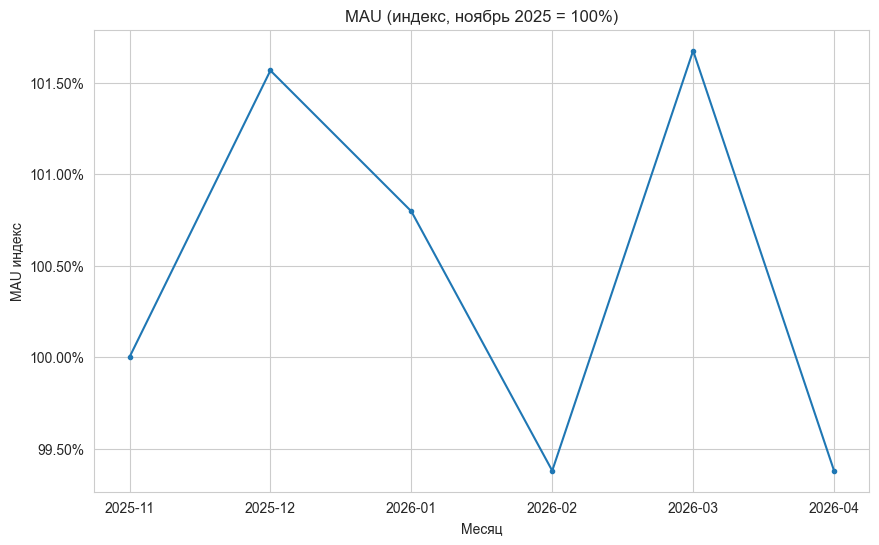

In [37]:
plt.figure(figsize=(10, 6))

plt.title('MAU (индекс, ноябрь 2025 = 100%)')
plt.xlabel('Месяц')
plt.ylabel('MAU индекс')

mau_indexed = monthly_funnel_statistics['client_id'] / monthly_funnel_statistics['client_id'].iloc[0] * 100

plt.plot(monthly_funnel_statistics['month'], mau_indexed, marker='.')

plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(100))

В MAU за апрель падение небольшое - около 2% относительно марта.

Далее построим динамику по конверсиям **в сессиях** (переходы между этапами воронки и конверсия в покупку):

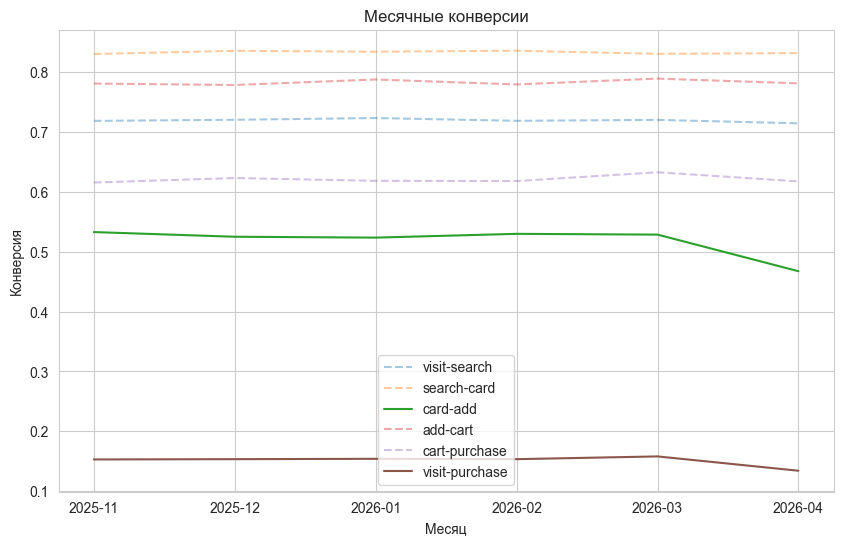

In [38]:
plt.figure(figsize=(10,6))

for conversion in conversions:
    # Plot
    if conversion in ['card-add', 'visit-purchase']:
        plt.plot(monthly_funnel_statistics['month'], monthly_funnel_statistics[conversion], label=conversion)
    else:
        plt.plot(monthly_funnel_statistics['month'], monthly_funnel_statistics[conversion], linestyle='--', alpha=0.4, label=conversion)

plt.xlabel('Месяц')
plt.ylabel('Конверсия')
plt.title('Месячные конверсии')

plt.grid(True)
plt.legend()
plt.show()

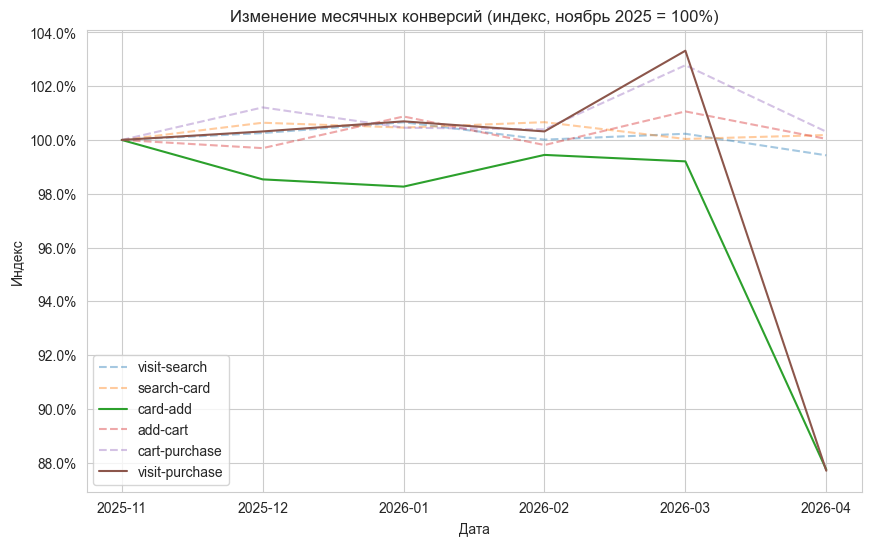

In [39]:
plt.figure(figsize=(10,6))

for conversion in conversions:
    conversion_data = monthly_funnel_statistics[conversion]
    conversion_indexed = conversion_data / conversion_data.iloc[0]
    conversion_indexed = conversion_indexed * 100

    # Plot
    if conversion in ['card-add', 'visit-purchase']:
        plt.plot(monthly_funnel_statistics['month'], conversion_indexed, label=conversion)
    else:
        plt.plot(monthly_funnel_statistics['month'], conversion_indexed, linestyle='--', alpha=0.4, label=conversion)


plt.xlabel('Дата')
plt.ylabel('Индекс')
plt.title('Изменение месячных конверсий (индекс, ноябрь 2025 = 100%)')

plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(100))

plt.grid(True)
plt.legend()
plt.show()

Конверсия в покупку в апреле испытывает сильное падение (около 15% относительно марта). **Ключевой этап воронки**, который повлиял на падение -- **переход из просмотра карточки в добавление в корзину**.

При этом поведение пользователей не меняется с точки зрения времени перехода между этапами:

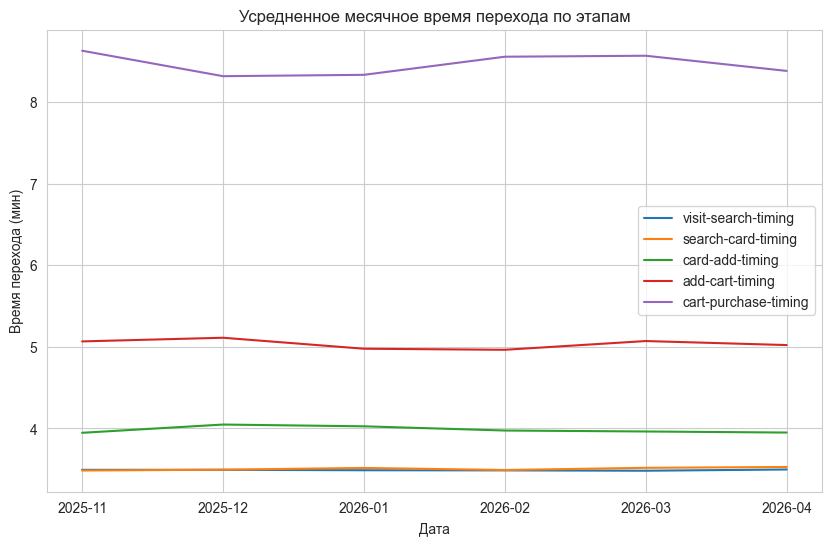

In [40]:
plt.figure(figsize=(10,6))

for conversion_timing in conversion_timings:
    
    conversion_timing_data = monthly_funnel_statistics[conversion_timing]

    # Plot
    plt.plot(monthly_funnel_statistics['month'], conversion_timing_data, label=conversion_timing)

plt.xlabel('Дата')
plt.ylabel('Время перехода (мин)')
plt.title('Усредненное месячное время перехода по этапам')

plt.grid(True)
plt.legend()
plt.show()

Посмотрим на конверсию в покупку по источнику трафика:

In [41]:
monthly_funnel_statistics_by_traffic = df_funnel.groupby(['month', 'traffic_source']).agg({
    'client_id': 'nunique',
    'service_visit': 'sum',
    'product_search': 'sum',
    'product_card_view': 'sum',
    'add_to_cart': 'sum',
    'cart_visit': 'sum',
    'purchase': 'sum',
    'visit-search-timing': 'mean',
    'search-card-timing': 'mean',
    'card-add-timing': 'mean',
    'add-cart-timing': 'mean',
    'cart-purchase-timing': 'mean'
}).reset_index()

conversions = ['visit-search', 'search-card', 'card-add', 'add-cart', 'cart-purchase', 'visit-purchase']

monthly_funnel_statistics_by_traffic['visit-search'] = monthly_funnel_statistics_by_traffic['product_search'] / monthly_funnel_statistics_by_traffic['service_visit']
monthly_funnel_statistics_by_traffic['search-card'] = monthly_funnel_statistics_by_traffic['product_card_view'] / monthly_funnel_statistics_by_traffic['product_search']
monthly_funnel_statistics_by_traffic['card-add'] = monthly_funnel_statistics_by_traffic['add_to_cart'] / monthly_funnel_statistics_by_traffic['product_card_view']
monthly_funnel_statistics_by_traffic['add-cart'] = monthly_funnel_statistics_by_traffic['cart_visit'] / monthly_funnel_statistics_by_traffic['add_to_cart']
monthly_funnel_statistics_by_traffic['cart-purchase'] = monthly_funnel_statistics_by_traffic['purchase'] / monthly_funnel_statistics_by_traffic['cart_visit']
monthly_funnel_statistics_by_traffic['visit-purchase'] = monthly_funnel_statistics_by_traffic['purchase'] / monthly_funnel_statistics_by_traffic['service_visit']

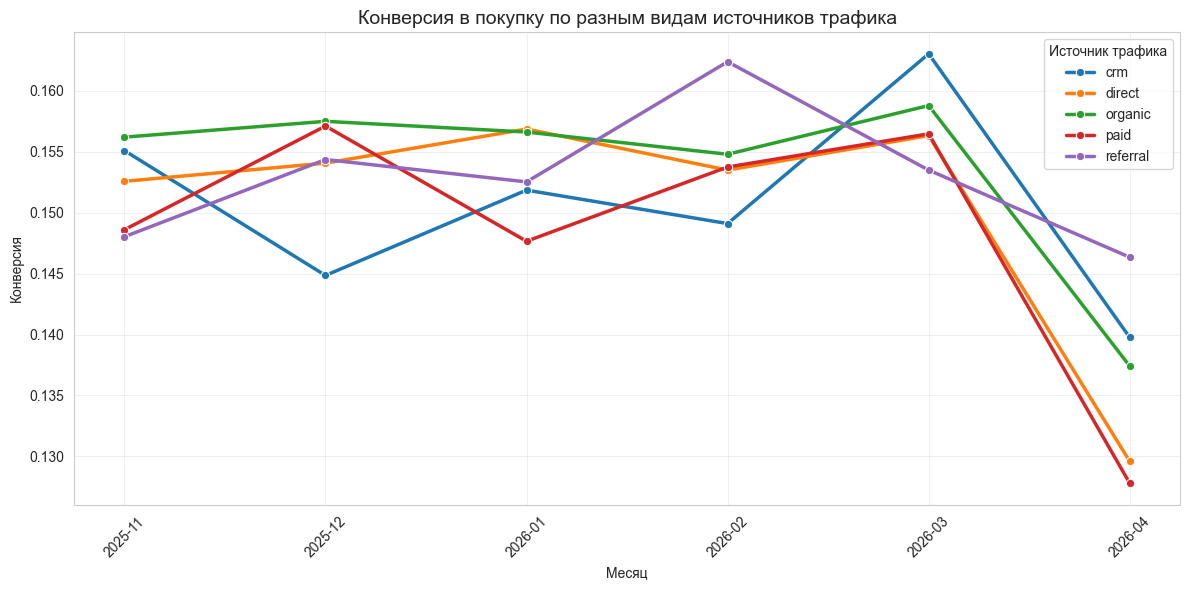

In [42]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_funnel_statistics_by_traffic, x='month', y='visit-purchase', hue='traffic_source', 
             marker='o', linewidth=2.5)

plt.title('Конверсия в покупку по разным видам источников трафика', fontsize=14)
plt.xlabel('Месяц')
plt.ylabel('Конверсия')
plt.legend(title='Источник трафика')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Заметна просадка по всем источникам.

### Анализ конверсии у клиентов и когортный анализ

#### Конверсия по пользователям

Определим, как конверсия меняется на уровне клиента:

In [43]:
funnel_user_statistics = df_funnel.groupby(['month', 'client_id']).agg({
    'service_visit': 'any',
    'product_search': 'any',
    'product_card_view': 'any',
    'add_to_cart': 'any',
    'cart_visit': 'any',
    'purchase': 'any'
}).reset_index()

funnel_user_statistics = funnel_user_statistics.groupby(['month']).agg({
    'service_visit': 'sum',
    'product_search': 'sum',
    'product_card_view': 'sum',
    'add_to_cart': 'sum',
    'cart_visit': 'sum',
    'purchase': 'sum'
}).reset_index()

conversions = ['visit-search', 'search-card', 'card-add', 'add-cart', 'cart-purchase', 'visit-purchase']

funnel_user_statistics['visit-search'] = funnel_user_statistics['product_search'] / funnel_user_statistics['service_visit']
funnel_user_statistics['search-card'] = funnel_user_statistics['product_card_view'] / funnel_user_statistics['product_search']
funnel_user_statistics['card-add'] = funnel_user_statistics['add_to_cart'] / funnel_user_statistics['product_card_view']
funnel_user_statistics['add-cart'] = funnel_user_statistics['cart_visit'] / funnel_user_statistics['add_to_cart']
funnel_user_statistics['cart-purchase'] = funnel_user_statistics['purchase'] / funnel_user_statistics['cart_visit']
funnel_user_statistics['visit-purchase'] = funnel_user_statistics['purchase'] / funnel_user_statistics['service_visit']

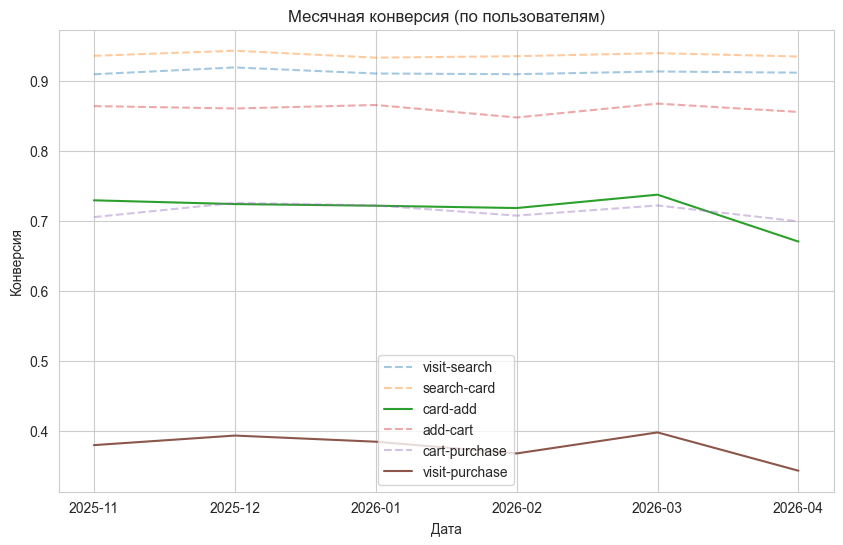

In [44]:
plt.figure(figsize=(10,6))

for conversion in conversions:
    
    conversion_data = funnel_user_statistics[conversion]

    # Plot
    if conversion in ['card-add', 'visit-purchase']:
        plt.plot(funnel_user_statistics['month'], conversion_data, label=conversion)
    else:
        plt.plot(funnel_user_statistics['month'], conversion_data, linestyle='--', alpha=0.4, label=conversion)


plt.xlabel('Дата')
plt.ylabel('Конверсия')
plt.title('Месячная конверсия (по пользователям)')

plt.grid(True)
plt.legend()
plt.show()

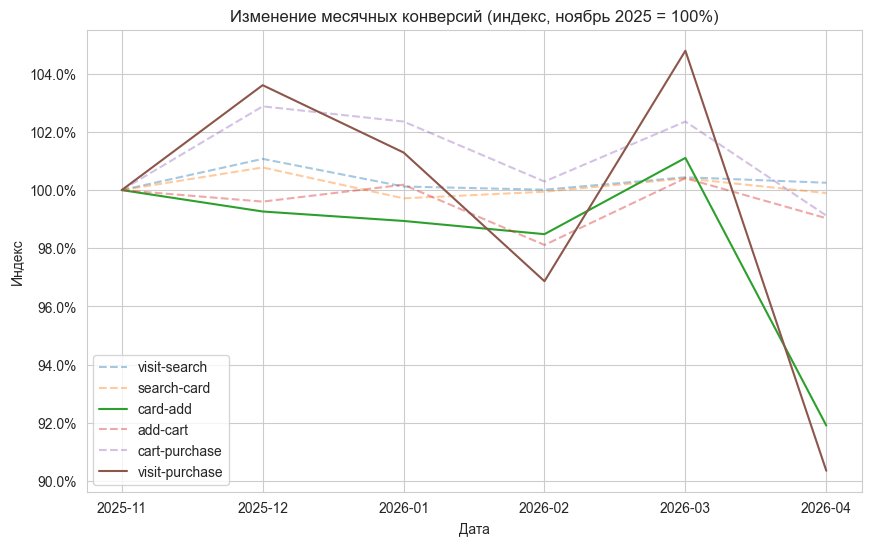

In [45]:
plt.figure(figsize=(10,6))

for conversion in conversions:
    conversion_data = funnel_user_statistics[conversion]
    conversion_indexed = conversion_data / conversion_data.iloc[0]
    conversion_indexed = conversion_indexed * 100

    # Plot
    if conversion in ['card-add', 'visit-purchase']:
        plt.plot(funnel_user_statistics['month'], conversion_indexed, label=conversion)
    else:
        plt.plot(funnel_user_statistics['month'], conversion_indexed, linestyle='--', alpha=0.4, label=conversion)


plt.xlabel('Дата')
plt.ylabel('Индекс')
plt.title('Изменение месячных конверсий (индекс, ноябрь 2025 = 100%)')

plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(100))

plt.grid(True)
plt.legend()
plt.show()

Наблюдаем аналогичный случай: падение конверсии в покупку за счет падения конверсии в переходе из карточки в добавление в корзину.

#### Когортный Анализ

Исследуем изменение в конверсии (**по пользователям**) у разных пользователей:
- новичков (первая сессия в текущем месяце);
- текущих клиентов (первая сессия до текущего месяца).

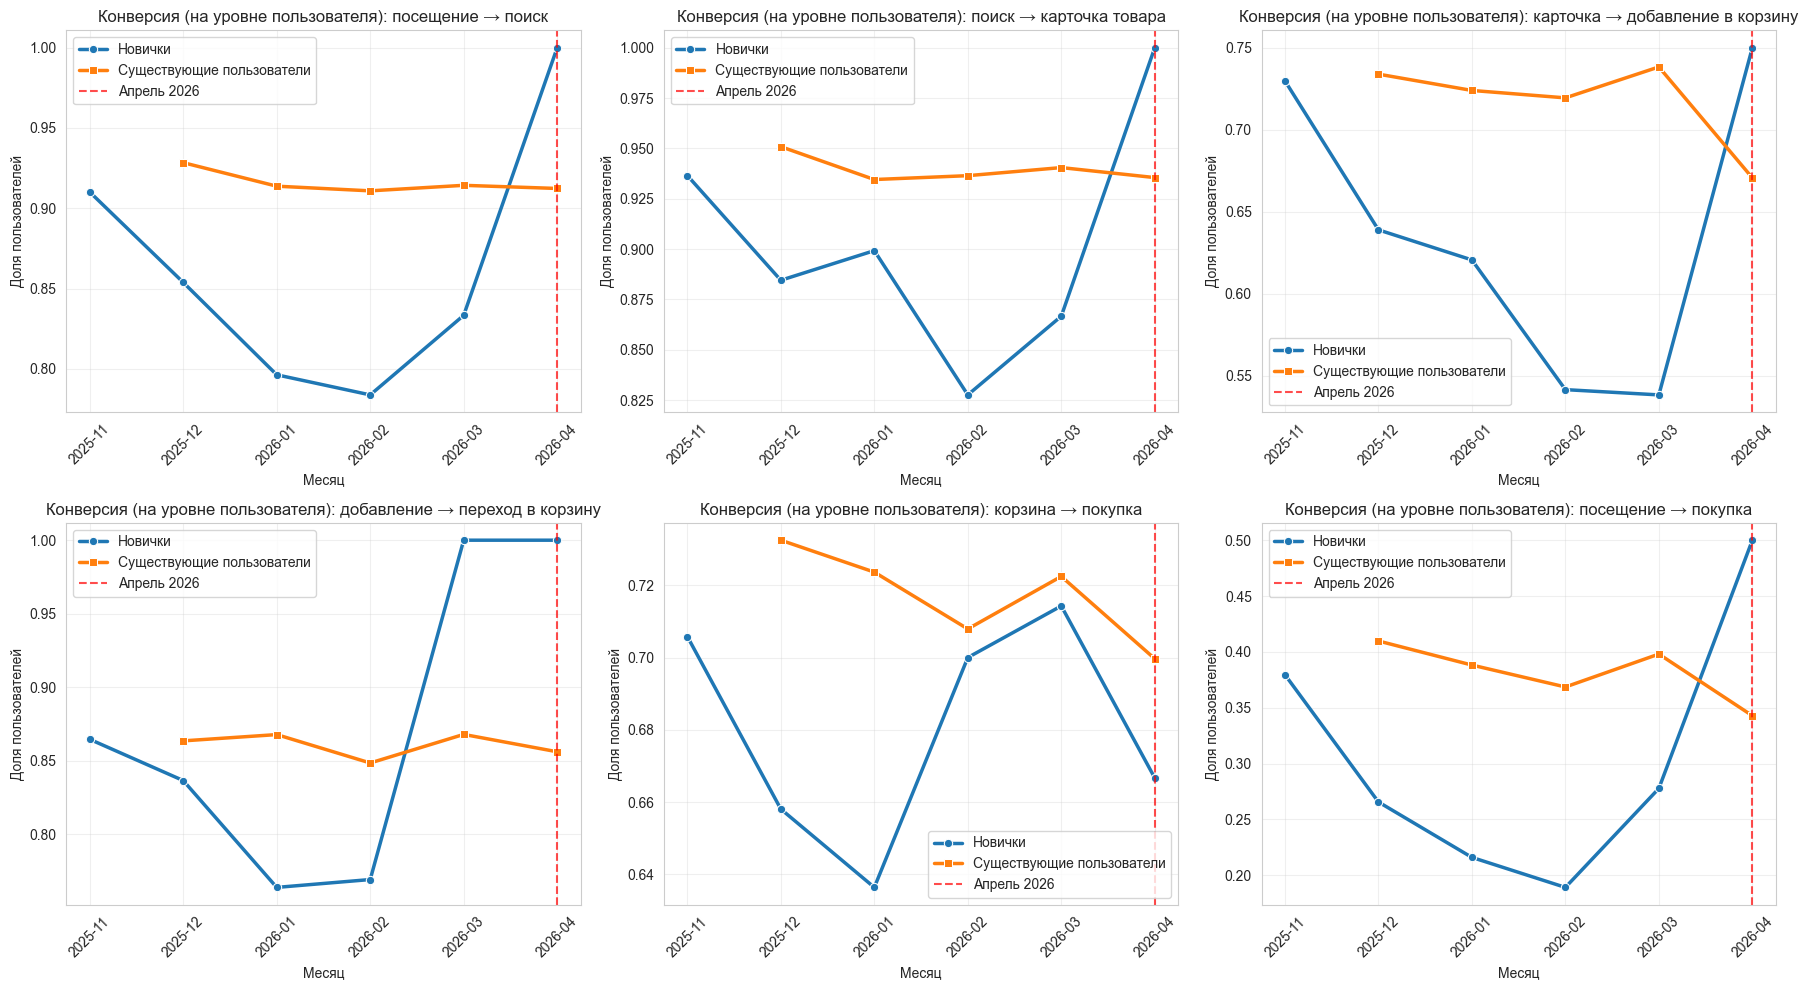

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define conversion steps
conversions = [
    ('service_visit', 'product_search', 'посещение → поиск'),
    ('product_search', 'product_card_view', 'поиск → карточка товара'),
    ('product_card_view', 'add_to_cart', 'карточка → добавление в корзину'),
    ('add_to_cart', 'cart_visit', 'добавление → переход в корзину'),
    ('cart_visit', 'purchase', 'корзина → покупка'),
    ('service_visit', 'purchase', 'посещение → покупка')
]

# Work on a copy
funnel = df_funnel.copy()
funnel['session_date'] = pd.to_datetime(funnel['session_date'])
funnel['session_month'] = funnel['session_date'].dt.strftime('%Y-%m')

# Compute each client's first session month
first_session = funnel.groupby('client_id')['session_date'].min().reset_index()
first_session.columns = ['client_id', 'first_session_date']
first_session['first_month'] = first_session['first_session_date'].dt.strftime('%Y-%m')
funnel = funnel.merge(first_session[['client_id', 'first_month']], on='client_id', how='left')

# Get sorted unique months
months = sorted(funnel['session_month'].unique())

# Create a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Loop over each conversion type
for idx, (denom_col, num_col, conv_name_ru) in enumerate(conversions):
    results = []
    
    for month in months:
        month_data = funnel[funnel['session_month'] == month].copy()
        
        # Newcomers: first session month == current month
        newcomers = month_data[month_data['first_month'] == month]
        # Existing users: first session month < current month
        existing = month_data[month_data['first_month'] < month]
        
        # ---- User-level conversion for newcomers ----
        if len(newcomers) > 0:
            # Group by client_id
            user_new = newcomers.groupby('client_id').agg(
                denom_user=(denom_col, 'max'),   # any session with denominator=1
                num_user=(num_col, 'max')        # any session with numerator=1
            ).reset_index()
            # Users who reached denominator
            denom_users = user_new[user_new['denom_user'] == 1]
            if len(denom_users) > 0:
                cr_new = denom_users['num_user'].mean()
            else:
                cr_new = None
        else:
            cr_new = None
        
        # ---- User-level conversion for existing users ----
        if len(existing) > 0:
            user_exist = existing.groupby('client_id').agg(
                denom_user=(denom_col, 'max'),
                num_user=(num_col, 'max')
            ).reset_index()
            denom_users = user_exist[user_exist['denom_user'] == 1]
            if len(denom_users) > 0:
                cr_exist = denom_users['num_user'].mean()
            else:
                cr_exist = None
        else:
            cr_exist = None
        
        results.append({
            'month': month,
            'newcomers': cr_new,
            'existing': cr_exist
        })
    
    df_monthly = pd.DataFrame(results)
    
    # Plot on the corresponding subplot
    ax = axes[idx]
    sns.lineplot(data=df_monthly, x='month', y='newcomers', ax=ax,
                 marker='o', label='Новички', linewidth=2.5)
    sns.lineplot(data=df_monthly, x='month', y='existing', ax=ax,
                 marker='s', label='Существующие пользователи', linewidth=2.5)
    
    # Mark April 2026
    if '2026-04' in df_monthly['month'].values:
        ax.axvline(x='2026-04', color='red', linestyle='--', alpha=0.7, label='Апрель 2026')
    
    ax.set_title(f'Конверсия (на уровне пользователя): {conv_name_ru}', fontsize=12)
    ax.set_xlabel('Месяц')
    ax.set_ylabel('Доля пользователей')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Падение конверсии в апреле 2026 года **изолировано на существующих пользователях**, которые являются основными получателями маркетинговых коммуникаций. Все этапы воронки для существующих пользователей ухудшились, в то время как **новые пользователи (не охваченные кампаниями) улучшили показатели**. Это убедительно указывает на то, что причиной падения GMV может быть связано с маркетинговыми коммуникациями, так как падение наблюдается только у существующих пользователей.

Несмотря на улучшение показателей у новых пользователей и исходя из абсолютных чисел, мы не можем уверенно говорить о повышении конверсии, так как число новичков стремительно падает до совсем малой группой в апреле:

In [47]:
user_first_session = df_funnel.groupby('client_id').agg(first_session=('session_date', 'min'))

user_first_session['first_session_month'] = user_first_session['first_session'].dt.strftime('%Y-%m')

print(user_first_session.groupby('first_session_month').agg(count=('first_session', 'count')).reset_index())

  first_session_month  count
0             2025-11   7408
1             2025-12    862
2             2026-01    162
3             2026-02     37
4             2026-03     18
5             2026-04      4


**Итог**: при анализе падения ключевой метрики и её компонент, изменения по новым пользователям отследить не получилось (группы невелики), поэтому итоговый вклад рекомендуется считать по всем пользоваетелям без разделения на вклад когорт.

### Анализ маркетинговых коммуникаций

Исходя из прошлых пунктов, ключевой эффект от падения конверсии (и GMV в том числе) может быть связан с изменением маркетинговых коммуникаций. Т.е. **бизнес-гипотеза состоит в том, что в апреле коммуникации привели к уменьшению интереса существующих пользователей в продукте**.

Для начала оценим, какие изменения произошли:

#### Частота коммуникаций

In [48]:
df_market['send_date'] = pd.to_datetime(df_market['send_date'])
df_market['send_month'] = df_market['send_date'].dt.strftime('%Y-%m')

daily_comm = df_market.groupby('send_month').size()

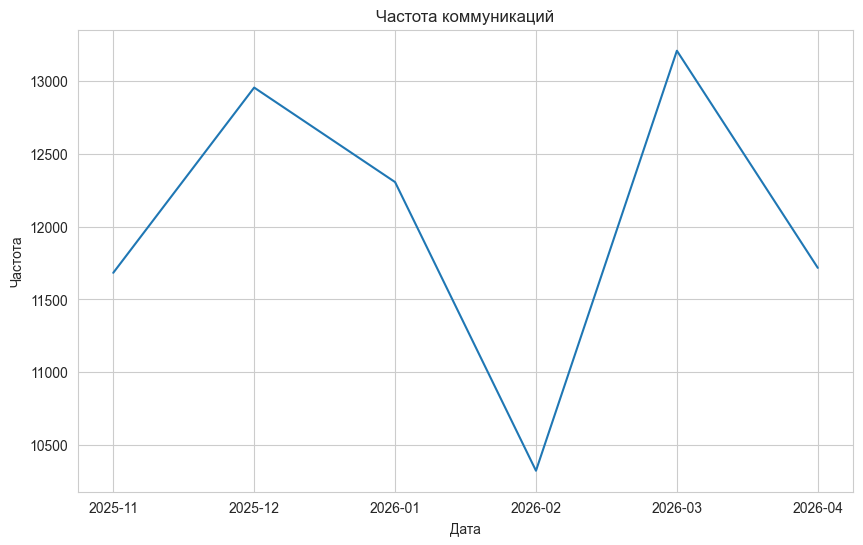

In [49]:
plt.figure(figsize=(10,6))

daily_comm.plot()

plt.xlabel('Дата')
plt.ylabel('Частота')
plt.title('Частота коммуникаций')

plt.grid(True)
plt.show()

Частота коммуникаций упала. Хотя при более сильном падении в январе-феврале, изменение конверсии у существующих пользователей было небольшим.

#### Время отправки

In [50]:
before_drop_marketing = df_market[df_market['send_date'] < '2026-04-01']
after_drop_marketing = df_market[df_market['send_date'] >= '2026-04-01']

<Figure size 1200x600 with 0 Axes>

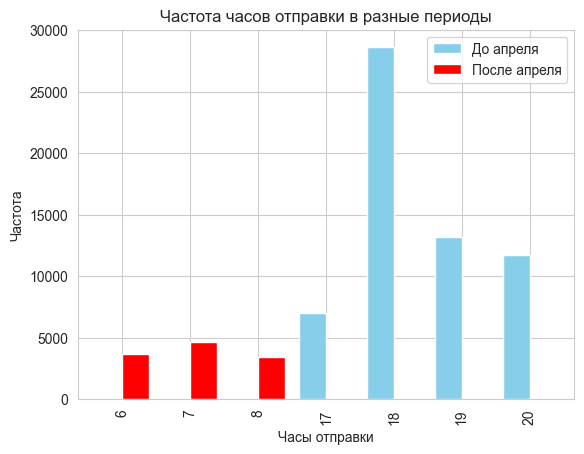

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Create a DataFrame with counts for each hour in both periods
hour_counts = pd.DataFrame({
    'До апреля': before_drop_marketing.groupby('send_hour').size(),
    'После апреля': after_drop_marketing.groupby('send_hour').size()
}).fillna(0)  # fill missing hours with 0 (if any hour appears only in one period)

# Plot side‑by‑side bars
hour_counts.plot(kind='bar', color=['skyblue', 'red'], width=0.8)

plt.xlabel('Часы отправки')
plt.ylabel('Частота')
plt.title('Частота часов отправки в разные периоды')
plt.grid(True, axis='y')
plt.legend()
plt.show()

<Figure size 1200x600 with 0 Axes>

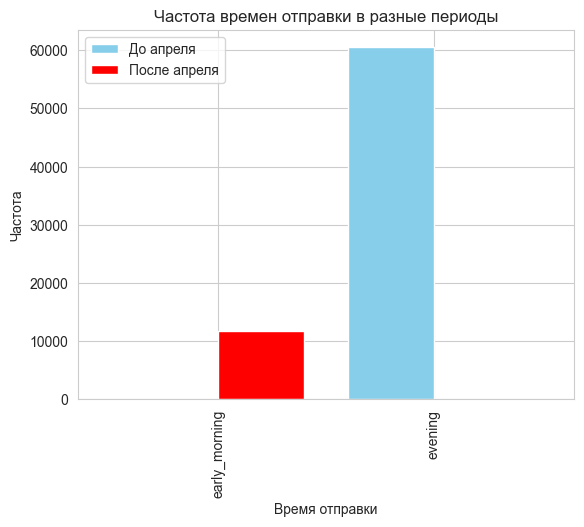

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

timing_counts = pd.DataFrame({
    'До апреля': before_drop_marketing.groupby('timing_period').size(),
    'После апреля': after_drop_marketing.groupby('timing_period').size()
}).fillna(0)

# Plot side‑by‑side bars
timing_counts.plot(kind='bar', color=['skyblue', 'red'], width=0.8)

plt.xlabel('Время отправки')
plt.ylabel('Частота')
plt.title('Частота времен отправки в разные периоды')
plt.grid(True, axis='y')
plt.legend()
plt.show()

Очевидно, что при новой политике **коммуникации стали отправлять ранним утром**, а не вечером.

#### Тип коммуникации

<Figure size 1200x600 with 0 Axes>

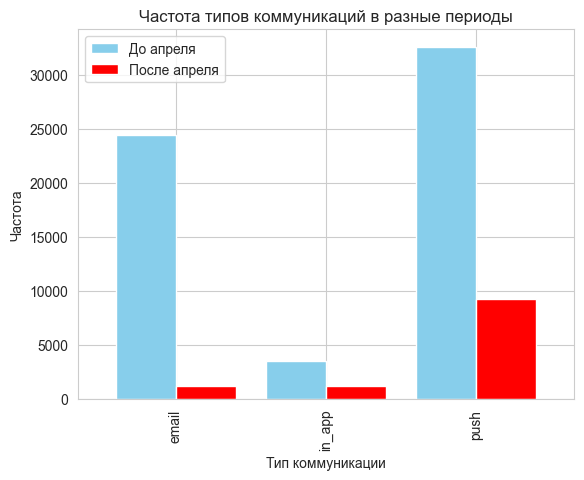

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

type_counts = pd.DataFrame({
    'До апреля': before_drop_marketing.groupby('communication_type').size(),
    'После апреля': after_drop_marketing.groupby('communication_type').size()
}).fillna(0)

# Plot side‑by‑side bars
type_counts.plot(kind='bar', color=['skyblue', 'red'], width=0.8)

plt.xlabel('Тип коммуникации')
plt.ylabel('Частота')
plt.title('Частота типов коммуникаций в разные периоды')
plt.grid(True, axis='y')
plt.legend()
plt.show()

**Изменились и пропорции каналов коммуникации**. После апреля пуши продолжили доминировать и прибавили в частоте. В отличие от них email-рассылка сократилась и стала на уровне коммуникаций в приложении.

In [54]:
from scipy.stats import chi2_contingency

contingency_table = type_counts.values

# Perform chi‑square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi2 statistic: {chi2:.4f}")
print(f"p-value: {p_value:.6f}")

Chi2 statistic: 3873.4253
p-value: 0.000000


Тест по пропорциям показывает статзначимые различия в распределении типов коммуникаций.

**Итог**: ключевые изменения в маркетинговых коммуникациях связаны в первую очередь с переносом времени отправки на раннее утро и перераспределении типов в пользу пушей.

### Итоговый вклад в изменение GMV

Составим итоговую диаграмму вклада разных компонент в падение GMV за апрель:

In [55]:
mar_orders_data = monthly_orders_statistics[monthly_orders_statistics['month'] == '2026-03'].iloc[0]
apr_orders_data = monthly_orders_statistics[monthly_orders_statistics['month'] == '2026-04'].iloc[0]

In [56]:
columns = ['service_visit', 'visit-search', 'search-card', 'card-add', 'add-cart', 'cart-purchase', 'visit-purchase']

mar_funnel_data = funnel_user_statistics[funnel_user_statistics['month']=='2026-03']
mar_funnel_data = mar_funnel_data[columns].rename(columns={'service_visit': 'mau'}).iloc[0]

apr_funnel_data = funnel_user_statistics[funnel_user_statistics['month']=='2026-04']
apr_funnel_data = apr_funnel_data[columns].rename(columns={'service_visit': 'mau'}).iloc[0]

In [57]:
mar_data = pd.concat([mar_orders_data, mar_funnel_data])
apr_data = pd.concat([apr_orders_data, apr_funnel_data])

#### Верхнеуровневый взгляд

GMV = Кол-во заказов * Cредний чек

Подсчитаем итоговое влияние на падение GMV по количеству заказов и среднему чеку:

In [58]:
# Total GMV change
total_change = apr_data['gmv'] - mar_data['gmv']

# Chain‑linking: orders first, then AOV
gmv_at_mar = apr_data['orders_count'] * mar_data['aov']
effect_orders = gmv_at_mar - mar_data['gmv']

gmv_at_both = apr_data['orders_count'] * apr_data['aov']
effect_aov = gmv_at_both - gmv_at_mar

# Results
high_level_impact = pd.DataFrame({
    'Component': ['orders_count', 'aov'],
    'Impact_abs': [effect_orders, effect_aov],
    'Share_%': [effect_orders/total_change*100, effect_aov/total_change*100]
})
print("High‑level decomposition")
print(high_level_impact)
print(f"Sum of impacts = {effect_orders + effect_aov:.2f} (target: {total_change:.2f})")

High‑level decomposition
      Component    Impact_abs    Share_%
0  orders_count -2.376338e+06  87.295311
1           aov -3.458449e+05  12.704689
Sum of impacts = -2722182.91 (target: -2722182.91)


In [59]:
import matplotlib.pyplot as plt
import numpy as np

def waterfall_plot(df, start_value, end_value, title="Waterfall plot", figsize=(10, 6), **kwargs):
    components = kwargs.get('components', df['Component'].tolist())
    impacts = df['Impact_abs'].tolist()
    shares = df['Share_%'].tolist()
    
    cum = np.cumsum([start_value] + impacts[:-1])
    starts = [start_value] + cum.tolist()
    
    bar_values = [start_value] + impacts + [end_value]
    colors = ['#2ecc71'] + ['#e74c3c' if imp < 0 else '#3498db' for imp in impacts] + ['#2ecc71']
    
    fig, ax = plt.subplots(figsize=figsize)
    
    for i, (val, color) in enumerate(zip(bar_values, colors)):
        if i == 0:
            ax.bar(i, val, width=0.85, color=color, alpha=0.8)
            ax.text(i, val/2, f'{val:,.0f}', ha='center', va='center', fontsize=9, color='white', weight='bold')
        elif i == len(bar_values)-1:
            ax.bar(i, val, width=0.85, color=color, alpha=0.8)
            ax.text(i, val/2, f'{val:,.0f}', ha='center', va='center', fontsize=9, color='white', weight='bold')
        else:
            prev_cum = start_value + sum(impacts[:i-1])
            bottom = prev_cum if val >= 0 else prev_cum + val
            height = abs(val)
            ax.bar(i, height, bottom=min(prev_cum, prev_cum+val), width=0.6, color=color, alpha=0.8)
            label = f'+{val:,.0f}\n({shares[i-1]:.1f}%)' if val > 0 else f'{val:,.0f}\n({shares[i-1]:.1f}%)'
            ax.text(i, prev_cum + val/2, label, ha='center', va='center', fontsize=8, weight='bold')
    
    x_labels = ['GMV в марте'] + components + ['GMV в апреле']
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(millions_formatter))
    ax.set_ylabel('GMV (млн. руб.)')
    ax.set_title(title)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    y_max = max(bar_values) * 1.05
    y_min = min(min(bar_values), 0) * 1.05
    ax.set_ylim(y_min, y_max)
    plt.tight_layout()
    plt.show()


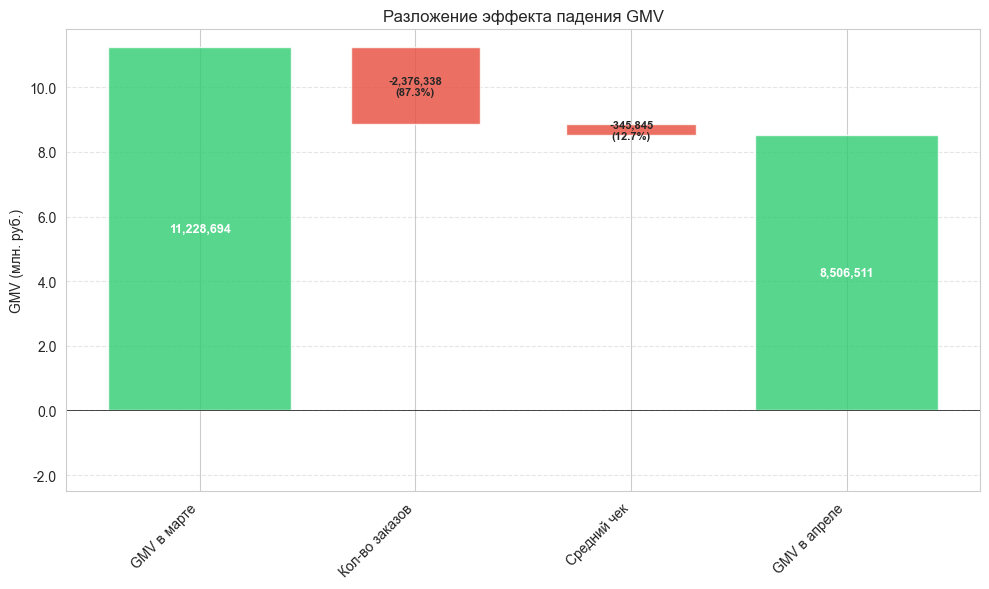

In [60]:
mar_gmv = mar_data['gmv']
apr_gmv = apr_data['gmv']

waterfall_plot(high_level_impact, mar_gmv, apr_gmv, title="Разложение эффекта падения GMV", components=['Кол-во заказов', 'Средний чек'])

#### Низкоуровневый взгляд

GMV = (MAU * конверсия в покупку) * среднее кол-во покупок * (средний размер корзины * средняя стоимость товаров)

In [61]:
import pandas as pd

# Copy data
mar = mar_data.copy()
apr = apr_data.copy()

# Add MAU alias (if not already present as 'MAU')
mar['MAU'] = mar['mau']
apr['MAU'] = apr['mau']

# Define factors in substitution order (matching column names)
factors = ['MAU', 'visit-purchase', 'average_orders_per_buyer', 
           'average_items_count', 'average_items_price']

def compute_gmv(values):
    return (values['MAU'] *
            values['visit-purchase'] *
            values['average_orders_per_buyer'] *
            values['average_items_count'] *
            values['average_items_price'])

mar_gmv = compute_gmv(mar)
apr_gmv = compute_gmv(apr)
total_change = apr_gmv - mar_gmv

temp_vals = mar.copy()
current_gmv = mar_gmv
effects = {}

for f in factors:
    temp_vals[f] = apr[f]
    new_gmv = compute_gmv(temp_vals)
    effects[f] = new_gmv - current_gmv
    current_gmv = new_gmv

low_impact = pd.DataFrame({
    'Component': factors,
    'Impact_abs': [effects[f] for f in factors],
    'Share_%': [effects[f] / total_change * 100 for f in factors]
})

print("Low‑level decomposition (GMV change from Mar to Apr)")
print(low_impact)
print(f"Sum of impacts = {sum(effects.values()):.2f} (target: {total_change:.2f})")

Low‑level decomposition (GMV change from Mar to Apr)
                  Component    Impact_abs    Share_%
0                       MAU -2.534357e+05   9.310019
1            visit-purchase -1.511823e+06  55.537154
2  average_orders_per_buyer -6.110794e+05  22.448138
3       average_items_count  7.206032e+04  -2.647152
4       average_items_price -4.179052e+05  15.351841
Sum of impacts = -2722182.91 (target: -2722182.91)


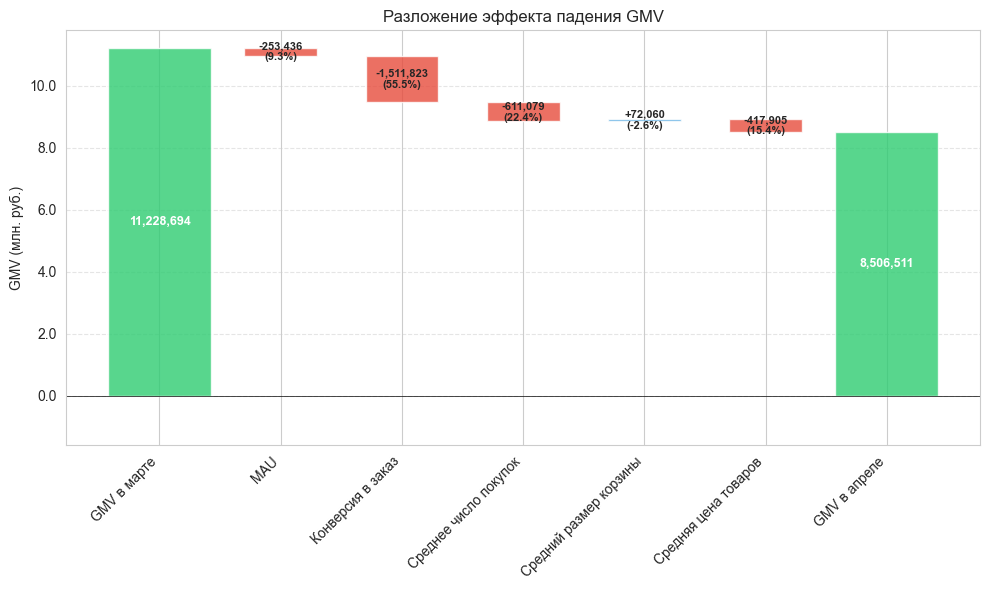

In [62]:
waterfall_plot(low_impact, mar_gmv, apr_gmv,
               title="Разложение эффекта падения GMV",
               components=['MAU', 'Конверсия в заказ', 'Среднее число покупок', 'Средний размер корзины', 'Средняя цена товаров'])

Рассмотрим всю воронку с конверсиями:

In [63]:
steps = ['visit-search', 'search-card', 'card-add', 'add-cart', 'cart-purchase']

mar_vp = mar_data['visit-purchase']
apr_vp = apr_data['visit-purchase']
total_vp_change = apr_vp - mar_vp

if total_vp_change != 0:
    mar_funnel = np.array([mar_data[s] for s in steps])
    apr_funnel = np.array([apr_data[s] for s in steps])
    
    log_total = np.log(apr_vp / mar_vp)
    contrib_pp = {}
    
    for i, step in enumerate(steps):
        temp = mar_funnel.copy()
        temp[i] = apr_funnel[i]
        temp_vp = temp.prod()
        log_contrib = np.log(temp_vp / mar_vp)
        share = log_contrib / log_total
        contrib_pp[step] = total_vp_change * share
    
    funnel_impact = pd.DataFrame({
        'Step': steps,
        'Contribution_pp': [contrib_pp[s] for s in steps],
        'Share_%': [contrib_pp[s]/total_vp_change*100 for s in steps]
    })
    print(funnel_impact)

            Step  Contribution_pp    Share_%
0   visit-search        -0.000693   1.264797
1    search-card        -0.001880   3.430266
2       card-add        -0.035260  64.352593
3       add-cart        -0.005099   9.305375
4  cart-purchase        -0.011861  21.646970


In [64]:
# All factors in substitution order
factors = [
    'MAU',
    'visit-search',
    'search-card',
    'card-add',
    'add-cart',
    'cart-purchase',
    'average_orders_per_buyer',
    'average_items_count',
    'average_items_price'
]

def compute_gmv(values):
    return (values['MAU'] *
            values['visit-search'] *
            values['search-card'] *
            values['card-add'] *
            values['add-cart'] *
            values['cart-purchase'] *
            values['average_orders_per_buyer'] *
            values['average_items_count'] *
            values['average_items_price'])

mar = mar_data.copy()
apr = apr_data.copy()
mar['MAU'] = mar['mau']
apr['MAU'] = apr['mau']

mar_gmv = compute_gmv(mar)
apr_gmv = compute_gmv(apr)
total_change = apr_gmv - mar_gmv

temp_vals = mar.copy()
current_gmv = mar_gmv
effects = {}

for f in factors:
    temp_vals[f] = apr[f]
    new_gmv = compute_gmv(temp_vals)
    effects[f] = new_gmv - current_gmv
    current_gmv = new_gmv

low_impact_cr = pd.DataFrame({
    'Component': factors,
    'Impact_abs': [effects[f] for f in factors],
    'Share_%': [effects[f]/total_change*100 for f in factors]
})
print(low_impact_cr)
print(f"Sum of impacts = {sum(effects.values()):.2f} (target: {total_change:.2f})")

                  Component     Impact_abs    Share_%
0                       MAU -253435.738861   9.310019
1              visit-search  -20554.180825   0.755062
2               search-card  -55551.610388   2.040701
3                  card-add -991481.296985  36.422288
4                  add-cart -135701.886744   4.985039
5             cart-purchase -308533.927095  11.334063
6  average_orders_per_buyer -611079.387701  22.448138
7       average_items_count   72060.317139  -2.647152
8       average_items_price -417905.198539  15.351841
Sum of impacts = -2722182.91 (target: -2722182.91)


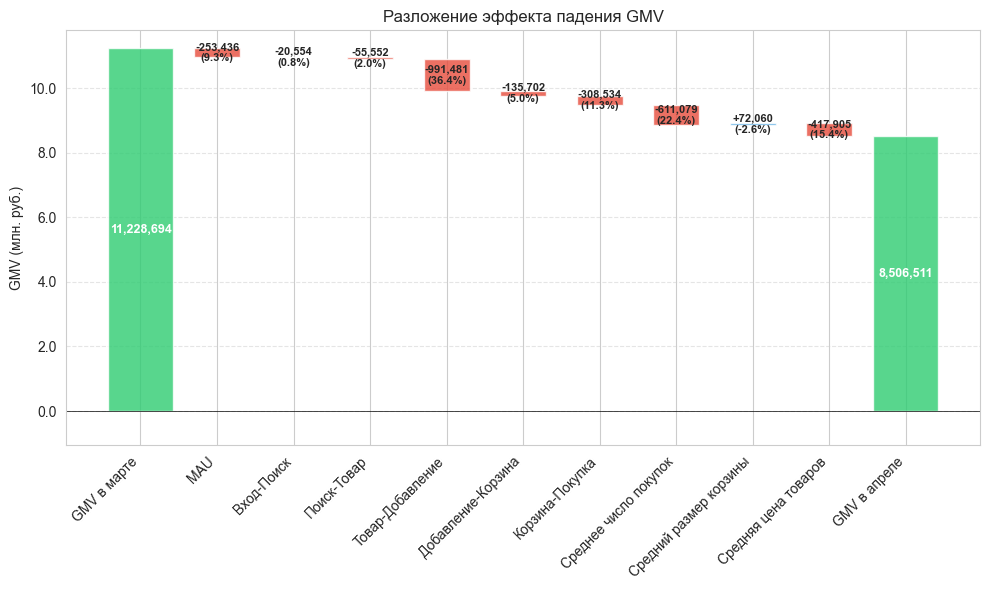

In [65]:
waterfall_plot(low_impact_cr, mar_gmv, apr_gmv,
               title="Разложение эффекта падения GMV",
               components=['MAU', 'Вход-Поиск', 'Поиск-Товар', 'Товар-Добавление', 'Добавление-Корзина', 'Корзина-Покупка', 'Среднее число покупок', 'Средний размер корзины', 'Средняя цена товаров'])

## 2. Анализ причин падения

### Подход

Собрав доступные данные и проведя анализ, мы локализовали проблему до:
1. Просадки конверсии в покупку (во многом через падение конверсии в переходе из карточки в добавление в корзину);
2. Уменьшении MAU;
3. Уменьшения среднего количества покупок на пользователя;
4. Уменьшения среднего чека (из-за падения средней цены товаров).

Проведем анализ влияния изменения маркетинговой политики. Наибольшее изменение притерпела конверсия в переходе из карточки в добавление в корзину, поэтому проведем исследование на ней. Для этого воспользуемся подготовленными группами пользователей, разбитых на тест и конроль.

**Процедура**:
1. Подсчитаем эффекты между тестом и контролем в экспериментах до апреля и после апреля.
2. Рассчитаем статзначимость различия распределений эффектов (T-test, Mann Whitney U Test).
3. Для надежности рассчитаем однородность выборок пользователей до и после апреля с помощью хи-квадрат теста по ключевым признакам (город, платформа, источник трафика). Также убедимся в отсутствии смещения в метриках между конрольными группами.

**Бизнес гипотеза**: изменение маркетинговых коммуникаций стало значимым фактором изменения конверсии из карточки в добавление в корзину.

### Подготовка данных

Объединим данные о заказах и воронке пользователя:

In [66]:
sessions_df = df_orders[
    ['order_id', 'session_id', 'client_id',
     'gross_merchandise_value', 'items_count', 'payment_method']
].merge(
    df_funnel[
        [
            'client_id',
            'session_id',
            'session_date',
            'campaign_id',
            'service_visit',
            'product_search',
            'product_card_view',
            'add_to_cart',
            'cart_visit',
            'purchase'
        ]
    ],
    how='right',
    on=['client_id', 'session_id']
)

Для тестов нам нужны все клиенты с полученными коммуникациями, даже если сессий у них не было:

In [67]:
df_market_unique = df_market[['client_id', 'campaign_id', 'experiment_group']].drop_duplicates()

sessions_marketing = sessions_df.merge(
    df_market_unique,
    how="right",
    on=["client_id", "campaign_id"]
)

sessions_marketing['session_date'] = pd.to_datetime(sessions_marketing['session_date'])

Агрегируем данные по клиентам, а далее по группе в эксперименте:

In [68]:
# Ensure session_date is datetime
sessions_marketing['session_date'] = pd.to_datetime(sessions_marketing['session_date'])

# Fill missing numeric columns with 0 (clients with no sessions)
numeric_cols = ['gross_merchandise_value', 'items_count', 'service_visit', 'product_search',
                'product_card_view', 'add_to_cart', 'cart_visit', 'purchase']
sessions_marketing[numeric_cols] = sessions_marketing[numeric_cols].fillna(0)

# 1. Client‑level aggregation per campaign
client_campaign = sessions_marketing.groupby(['client_id', 'campaign_id', 'experiment_group', 'session_date']).agg(
    purchase=('purchase', 'max'),
    gmv=('gross_merchandise_value', 'sum'),
    orders_count=('order_id', 'count'),
    service_visit=('service_visit', 'max'),
    product_search=('product_search', 'max'),
    product_card_view=('product_card_view', 'max'),
    add_to_cart=('add_to_cart', 'max'),
    cart_visit=('cart_visit', 'max')
).reset_index()

# Compute client‑level funnel conversion flags
client_campaign['card_add'] = ((client_campaign['product_card_view'] == 1) & 
                                (client_campaign['add_to_cart'] == 1)).astype(int)
client_campaign['visit_search'] = ((client_campaign['service_visit'] == 1) & 
                                   (client_campaign['product_search'] == 1)).astype(int)
client_campaign['search_card'] = ((client_campaign['product_search'] == 1) & 
                                  (client_campaign['product_card_view'] == 1)).astype(int)
client_campaign['add_cart'] = ((client_campaign['add_to_cart'] == 1) & 
                               (client_campaign['cart_visit'] == 1)).astype(int)
client_campaign['cart_purchase'] = ((client_campaign['cart_visit'] == 1) & 
                                    (client_campaign['purchase'] == 1)).astype(int)

# 2. Campaign‑level aggregation (per experiment group)
campaign_metrics = client_campaign.groupby(['campaign_id', 'experiment_group', 'session_date']).agg(
    clients=('client_id', 'count'),
    purchasers=('purchase', 'sum'),
    total_gmv=('gmv', 'sum'),
    total_orders=('orders_count', 'sum'),
    card_view_clients=('product_card_view', 'sum'),
    card_add_success=('card_add', 'sum'),
    visit_search_success=('visit_search', 'sum'),
    search_card_success=('search_card', 'sum'),
    add_cart_success=('add_cart', 'sum'),
    cart_purchase_success=('cart_purchase', 'sum')
).reset_index()

# 3. Compute conversion rates (use 0 denominator protection)
campaign_metrics['conversion_rate'] = campaign_metrics['purchasers'] / campaign_metrics['clients']
campaign_metrics['aov'] = campaign_metrics['total_gmv'] / campaign_metrics['total_orders'].replace(0, np.nan)
campaign_metrics['avg_orders_per_buyer'] = campaign_metrics['total_orders'] / campaign_metrics['purchasers'].replace(0, np.nan)
campaign_metrics['card_add_conversion'] = campaign_metrics['card_add_success'] / campaign_metrics['card_view_clients'].replace(0, np.nan)
campaign_metrics['visit_search_conversion'] = campaign_metrics['visit_search_success'] / campaign_metrics['clients'].replace(0, np.nan)
campaign_metrics['search_card_conversion'] = campaign_metrics['search_card_success'] / campaign_metrics['clients'].replace(0, np.nan)
campaign_metrics['add_cart_conversion'] = campaign_metrics['add_cart_success'] / campaign_metrics['clients'].replace(0, np.nan)
campaign_metrics['cart_purchase_conversion'] = campaign_metrics['cart_purchase_success'] / campaign_metrics['clients'].replace(0, np.nan)

campaign_metrics.head()

,campaign_id,experiment_group,session_date,clients,purchasers,total_gmv,total_orders,card_view_clients,card_add_success,visit_search_success,...,add_cart_success,cart_purchase_success,conversion_rate,aov,avg_orders_per_buyer,card_add_conversion,visit_search_conversion,search_card_conversion,add_cart_conversion,cart_purchase_conversion
0,CMP0001,control,2025-11-01,44,10.0,29583.63,10,28.0,19,33,...,15,10,0.227273,2958.363000,1.0,0.678571,0.750000,0.636364,0.340909,0.227273
1,CMP0001,test,2025-11-01,51,8.0,24837.11,8,26.0,17,33,...,12,8,0.156863,3104.638750,1.0,0.653846,0.647059,0.509804,0.235294,0.156863
2,CMP0002,control,2025-11-04,65,7.0,27126.58,7,40.0,20,44,...,16,7,0.107692,3875.225714,1.0,0.500000,0.676923,0.615385,0.246154,0.107692
3,CMP0002,test,2025-11-04,66,12.0,28327.49,12,50.0,28,57,...,18,12,0.181818,2360.624167,1.0,0.560000,0.863636,0.757576,0.272727,0.181818
4,CMP0003,control,2025-11-07,61,10.0,29005.23,10,35.0,19,45,...,17,10,0.163934,2900.523000,1.0,0.542857,0.737705,0.573770,0.278689,0.163934


In [69]:
campaign_metrics = campaign_metrics.set_index(['campaign_id', 'experiment_group'])

### Проведение теста

In [70]:
from scipy.stats import ttest_ind, mannwhitneyu

# Define the list of target metrics
target_metrics = [
    'card_add_conversion'
]

# Dictionary to store results for each metric
results = {metric: {'before': [], 'after': []} for metric in target_metrics}

# Get unique campaign ids
campaigns = campaign_metrics.index.get_level_values('campaign_id').unique()

for metric in target_metrics:
    effects_before = []
    effects_after = []
    
    for camp in campaigns:
        try:
            # Extract values for control and test groups
            control_val = campaign_metrics.loc[(camp, 'control'), metric]
            control_date = campaign_metrics.loc[(camp, 'control'), 'session_date']
            
            test_val = campaign_metrics.loc[(camp, 'test'), metric]
            test_date = campaign_metrics.loc[(camp, 'test'), 'session_date']
            
            # Calculate effect (test - control)
            effect = test_val - control_val
            
            # Ensure both groups belong to the same date
            assert control_date == test_date, f"Date mismatch for campaign {camp}"
            
            # Split into before/after April 1, 2026
            if control_date < pd.to_datetime('2026-04-01'):
                effects_before.append(effect)
            else:
                effects_after.append(effect)
                
        except (KeyError, IndexError, TypeError, AssertionError) as e:
            print(f"Missing data for campaign {camp}, metric {metric}: {e}")
    
    results[metric]['before'] = effects_before
    results[metric]['after'] = effects_after

# Display results and run statistical tests
for metric in target_metrics:
    before = results[metric]['before']
    after = results[metric]['after']
    
    if len(before) > 1 and len(after) > 1:
        # Welch's t-test (unequal variance)
        t_stat, p_t = ttest_ind(before, after, equal_var=False)
        # Mann-Whitney U test (non-parametric)
        u_stat, p_mw = mannwhitneyu(before, after, alternative='two-sided')
        
        print(f"\nMetric: {metric}")
        print(f"  Mean effect before April: {np.mean(before):.6f}")
        print(f"  Mean effect after April:  {np.mean(after):.6f}")
        print(f"  t-test p-value: {p_t:.6f}")
        print(f"  Mann-Whitney p-value: {p_mw:.6f}")
    else:
        print(f"\nMetric: {metric} - insufficient data (before: {len(before)}, after: {len(after)})")


Metric: card_add_conversion
  Mean effect before April: 0.108850
  Mean effect after April:  0.005614
  t-test p-value: 0.045519
  Mann-Whitney p-value: 0.027030


При уровне значимости 5% конверсия из просмотра карточки в добавление в корзину имеет статистическое подтверждение влияния изменения маркетинговых коммуникаций.

Проведем анализ однороднисти выборок:

In [71]:
from scipy.stats import chi2_contingency

control = df_funnel[df_funnel['experiment_group'] == 'control'].copy()
control['session_date'] = pd.to_datetime(control['session_date'])

# Get first session date per client
first_session = control.groupby('client_id')['session_date'].min().reset_index()
first_session.columns = ['client_id', 'first_session_date']
first_session['period'] = 'before'
first_session.loc[first_session['first_session_date'] >= '2026-04-01', 'period'] = 'after'

# Merge back to get attributes (use any row per client, e.g., first session)
client_attrs = control.drop_duplicates('client_id')[['client_id', 'city', 'platform', 'traffic_source']]
client_info = first_session.merge(client_attrs, on='client_id', how='left')

# Test each attribute
attributes = ['city', 'platform', 'traffic_source']
for attr in attributes:
    # Contingency table: rows = attribute values, columns = period
    ct = pd.crosstab(client_info[attr], client_info['period'])
    chi2, p, dof, expected = chi2_contingency(ct)
    print(f"Attribute: {attr:15} | p-value = {p:.6f} | Significant at 0.05? {p < 0.05}")

Attribute: city            | p-value = 0.134146 | Significant at 0.05? False
Attribute: platform        | p-value = 0.285393 | Significant at 0.05? False
Attribute: traffic_source  | p-value = 0.658129 | Significant at 0.05? False


Значимых изменений по срезам не наблюдается, можем сделать вывод об однородности пользователей из контрольных групп до и после изменения.

Проверим отсутствие смещения в целевой конверсии между контрольными группами до и после изменения:

In [72]:
control_before = [campaign_metrics.loc[(campaign, 'control')]['card_add_conversion'] for campaign in campaigns if campaign_metrics.loc[(campaign, 'control')]['session_date'] < pd.to_datetime('2026-04-01')]
control_after  = [campaign_metrics.loc[(campaign, 'control')]['card_add_conversion'] for campaign in campaigns if campaign_metrics.loc[(campaign, 'control')]['session_date'] >= pd.to_datetime('2026-04-01')]

# Two-sample t-test (or Mann-Whitney)
from scipy.stats import ttest_ind
t_stat, p_ctrl = ttest_ind(control_before, control_after, equal_var=False)
print(f"Mean control conversion before: {np.mean(control_before):.4f}")
print(f"Mean control conversion after:  {np.mean(control_after):.4f}")
print(f"p-value for difference: {p_ctrl:.4f}")

Mean control conversion before: 0.5203
Mean control conversion after:  0.4734
p-value for difference: 0.2857


При уровне значимости 5% нет достаточных сведений, чтобы сказать, что смещение наблюдается.

## 3. Расчеты и визуализация

На этом этапе соберем ключевые расчеты и визуализации, которые подтверждают причину падения оборота сервиса.

### Падение ключевой метрики

Сначала посмотрим на итоговое изменение GMV и разложим его на основные компоненты. Затем спустимся ниже по дереву метрик и проверим, на каком именно этапе воронки произошло ухудшение. В конце отдельно оценим влияние маркетинговых коммуникаций.

,month,gmv,orders_count,clients_count
0,2025-11,10693902.34,3659,2812
1,2025-12,11573313.28,3942,2959
2,2026-01,10874341.65,3719,2871
3,2026-02,10250867.63,3491,2707
4,2026-03,11573997.82,3955,2996
5,2026-04,8797446.90,3118,2525


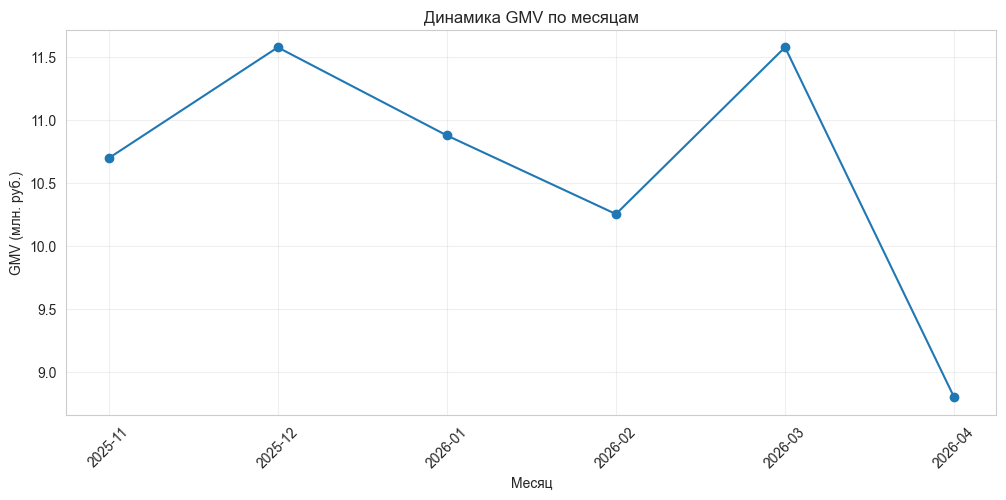

GMV в марте 2026: 11,573,998
GMV в апреле 2026: 8,797,447
Изменение: -2,776,551 (-23.99%)


In [73]:
# Динамика GMV по месяцам
gmv_monthly = (
    df_orders
    .assign(month=pd.to_datetime(df_orders['order_date']).dt.to_period('M').astype(str))
    .groupby('month', as_index=False)
    .agg(gmv=('paid_amount', 'sum'),
         orders_count=('order_id', 'nunique'),
         clients_count=('client_id', 'nunique'))
)

display(gmv_monthly)

plt.figure(figsize=(12, 5))
plt.plot(gmv_monthly['month'], gmv_monthly['gmv'], marker='o')
plt.title('Динамика GMV по месяцам')
plt.xlabel('Месяц')
plt.ylabel('GMV (млн. руб.)')
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(millions_formatter))
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

mar_gmv = gmv_monthly.loc[gmv_monthly['month'] == '2026-03', 'gmv'].iloc[0]
apr_gmv = gmv_monthly.loc[gmv_monthly['month'] == '2026-04', 'gmv'].iloc[0]

print(f'GMV в марте 2026: {mar_gmv:,.0f}')
print(f'GMV в апреле 2026: {apr_gmv:,.0f}')
print(f'Изменение: {apr_gmv - mar_gmv:,.0f} ({(apr_gmv / mar_gmv - 1) * 100:.2f}%)')

### Верхнеуровневое разложение GMV

Разложим GMV на два основных компонента:

**GMV = Кол-во заказов × Средний чек**

Это покажет, что именно сильнее повлияло на падение оборота: количество заказов или средний чек.

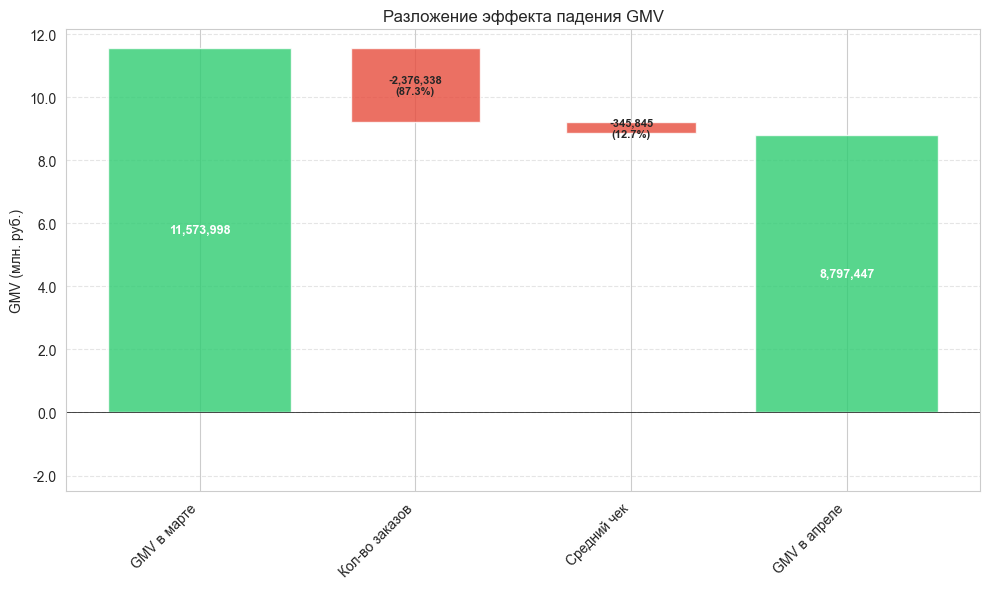

In [74]:
waterfall_plot(high_level_impact, mar_gmv, apr_gmv, title="Разложение эффекта падения GMV", components=['Кол-во заказов', 'Средний чек'])

### Низкоуровневое разложение

Теперь спустимся ниже по дереву метрик и посмотрим, за счет чего изменилось число заказов и средний чек.

Здесь важно понять, на каком этапе цепочки произошло основное ухудшение.

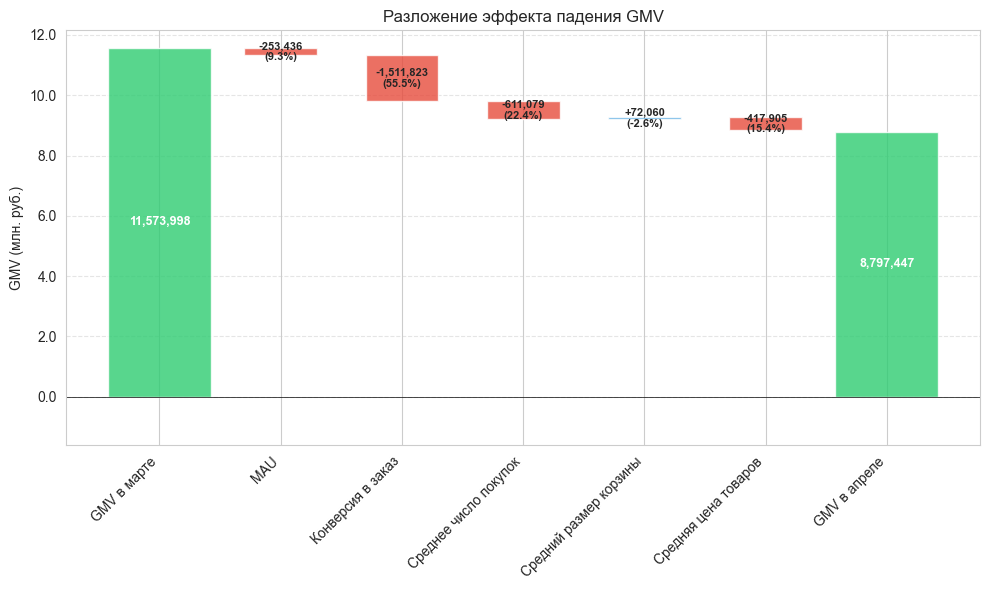

In [75]:
waterfall_plot(low_impact, mar_gmv, apr_gmv,
               title="Разложение эффекта падения GMV",
               components=['MAU', 'Конверсия в заказ', 'Среднее число покупок', 'Средний размер корзины', 'Средняя цена товаров'])

### Анализ воронки

Проверим, на каком этапе пользовательской воронки произошло наиболее заметное ухудшение.

Особое внимание уделим переходу **из карточки товара в добавление в корзину**, так как именно он чаще всего объясняет падение покупательской активности.

In [76]:
funnel_user_statistics = df_funnel.groupby(['month', 'client_id']).agg({
    'service_visit': 'any',
    'product_search': 'any',
    'product_card_view': 'any',
    'add_to_cart': 'any',
    'cart_visit': 'any',
    'purchase': 'any'
}).reset_index()

funnel_user_statistics = funnel_user_statistics.groupby(['month']).agg({
    'service_visit': 'sum',
    'product_search': 'sum',
    'product_card_view': 'sum',
    'add_to_cart': 'sum',
    'cart_visit': 'sum',
    'purchase': 'sum'
}).reset_index()

conversions = ['visit-search', 'search-card', 'card-add', 'add-cart', 'cart-purchase', 'visit-purchase']

funnel_user_statistics['visit-search'] = funnel_user_statistics['product_search'] / funnel_user_statistics['service_visit']
funnel_user_statistics['search-card'] = funnel_user_statistics['product_card_view'] / funnel_user_statistics['product_search']
funnel_user_statistics['card-add'] = funnel_user_statistics['add_to_cart'] / funnel_user_statistics['product_card_view']
funnel_user_statistics['add-cart'] = funnel_user_statistics['cart_visit'] / funnel_user_statistics['add_to_cart']
funnel_user_statistics['cart-purchase'] = funnel_user_statistics['purchase'] / funnel_user_statistics['cart_visit']
funnel_user_statistics['visit-purchase'] = funnel_user_statistics['purchase'] / funnel_user_statistics['service_visit']

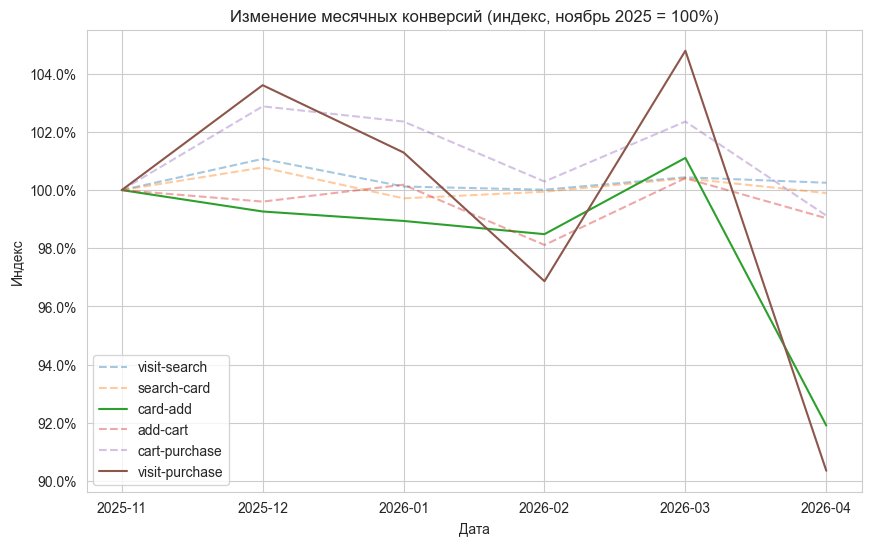

In [77]:
plt.figure(figsize=(10,6))

for conversion in conversions:
    conversion_data = funnel_user_statistics[conversion]
    conversion_indexed = conversion_data / conversion_data.iloc[0]
    conversion_indexed = conversion_indexed * 100

    # Plot
    if conversion in ['card-add', 'visit-purchase']:
        plt.plot(funnel_user_statistics['month'], conversion_indexed, label=conversion)
    else:
        plt.plot(funnel_user_statistics['month'], conversion_indexed, linestyle='--', alpha=0.4, label=conversion)


plt.xlabel('Дата')
plt.ylabel('Индекс')
plt.title('Изменение месячных конверсий (индекс, ноябрь 2025 = 100%)')

plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(100))

plt.grid(True)
plt.legend()
plt.show()

### Проверка влияния маркетинга

Сравним динамику по экспериментальным группам и посмотрим, есть ли заметное отличие между контрольной и тестовой группами.

Если падение наблюдается только в тесте, это может говорить о влиянии коммуникаций. Если падение одинаковое, значит причина, скорее всего, лежит шире, чем маркетинг.

C:\Users\ilya-\AppData\Local\Temp\ipykernel_8604\4141364017.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


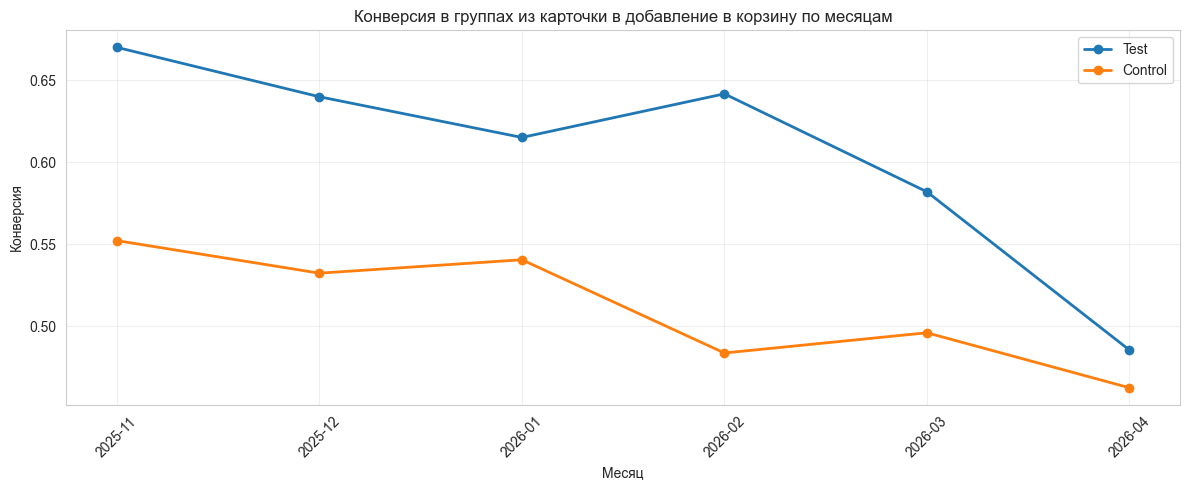

In [78]:
campaign_monthly = (
    campaign_metrics
    .assign(month=campaign_metrics['session_date'].dt.to_period('M').astype(str))
    .groupby(['month', 'experiment_group'])
    .apply(
        lambda x: pd.Series({
            'card_add_conversion': np.average(
                x['card_add_conversion'],
                weights=x['card_view_clients']
            )
        })
    )
    .reset_index()
)

plt.figure(figsize=(12, 5))

for group in ['test', 'control']:
    temp = campaign_monthly[
        campaign_monthly['experiment_group'] == group
    ]

    plt.plot(
        temp['month'],
        temp['card_add_conversion'],
        marker='o',
        linewidth=2,
        label=group.capitalize()
    )

plt.title('Конверсия в группах из карточки в добавление в корзину по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Конверсия')
plt.grid(alpha=0.3)
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Как мы видим, падение в тестовой группе визаульно больше. Однако для доказательности, требуется провести статистический тест.

### Проверка статистической значимости

Проверим, можно ли считать различия между мартом и апрелем статистически значимыми для ключевых этапов воронки.

Это нужно, чтобы не ограничиваться только визуальной оценкой.

In [79]:
# Display results and run statistical tests
for metric in target_metrics:
    before = results[metric]['before']
    after = results[metric]['after']
    
    if len(before) > 1 and len(after) > 1:
        # Welch's t-test (unequal variance)
        t_stat, p_t = ttest_ind(before, after, equal_var=False)
        # Mann-Whitney U test (non-parametric)
        u_stat, p_mw = mannwhitneyu(before, after, alternative='two-sided')
        
        print(f"\nMetric: {metric}")
        print(f"  Mean effect before April: {np.mean(before):.6f}")
        print(f"  Mean effect after April:  {np.mean(after):.6f}")
        print(f"  t-test p-value: {p_t:.6f}")
        print(f"  Mann-Whitney p-value: {p_mw:.6f}")
    else:
        print(f"\nMetric: {metric} - insufficient data (before: {len(before)}, after: {len(after)})")


Metric: card_add_conversion
  Mean effect before April: 0.108850
  Mean effect after April:  0.005614
  t-test p-value: 0.045519
  Mann-Whitney p-value: 0.027030


В итоге, при 5% уровне значимости мы имеем достаточно статистических сведений, чтобы отклонить гипотезу об отсутствии различий в изменении конверсии (из карточки в добавление в корзину) между периодами до и после апреля. Результаты согласуются с гипотезой о влиянии изменений маркетинговых коммуникаций.

## Выводы

Завершая исследование, я подвожу итоги в основных причинах падения ключевой метрики, указываю на проблемные места, а также даю рекомендации для бизнеса.

### Причины влияния на падение GMV

Ключевая метрика GMV значительно снизилась в апреле 2026 года относительно марта 2026 года.

Основной вклад в падение внесло сокращение числа заказов и покупателей. Дополнительный негативный вклад внесло снижение среднего чека, однако его влияние было существенно слабее.

Покупателей в свою очередь стало меньше из-за уменьшения конверсии в покупку. Наиболее заметное ухудшение воронки произошло на этапе перехода из просмотра карточки товара в добавление товара в корзину.

### Влияние маркетинга

Маркетинговые коммуникации притерпели изменения в апреле 2026 года: отправки переместили на раннее утро, email-рассылка уменьшилась, увеличилась рассылка push-уведомлениями.

Для проверки влияния маркетинговых изменений была выдвинута гипотеза о том, что изменение времени и каналов коммуникации повлияло на конверсию пользователей.

Сравнение контрольной и тестовой групп до и после апреля показало статистически значимое изменение разницы конверсий между группами. Это подтверждает, что изменения в маркетинговых коммуникациях могли стать одним из факторов снижения конверсии.

### Прочие выводы

Дополнительно было обнаружено устойчивое снижение числа новых пользователей на протяжении всего анализируемого периода. Хотя этот фактор не объясняет резкое падение GMV в апреле, он может представлять долгосрочный риск для роста сервиса.

### Рекомендации

Итого бизнесу рекомендуется:
- Провести дополнительную проверку изменений маркетинговых коммуникаций и оценить влияние отдельных каналов и времени отправки на конверсию пользователей.
- Вернуть A/B-тестирование изменений перед их массовым внедрением.
- Проанализировать причины снижения притока новых пользователей и оценить эффективность каналов привлечения.
- Организовать мониторинг ключевых этапов воронки, особенно перехода из карточки товара в добавление товара в корзину.

### Краткий итог

GMV в апреле 2026 года снизился преимущественно из-за сокращения числа заказов.

Основной причиной сокращения заказов стало ухудшение конверсии пользователей, прежде всего на этапе перехода из карточки товара в корзину.

Изменения маркетинговых коммуникаций, внедренные в апреле, статистически связаны с ухудшением данной конверсии и рассматриваются как один из наиболее вероятных факторов падения.

Дополнительно наблюдается устойчивое снижение притока новых пользователей, представляющее долгосрочный риск для роста бизнеса.